In [2]:
import numpy as np
import pandas as pd
import matplotlib 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
hr= pd.read_csv("E:\DS Course\Capstone Project\HR Data_Capstone Project\expected_ctc.csv")
hr.head()           

,IDX,Applicant_ID,Total_Experience,Total_Experience_in_field_applied,Department,Role,Industry,Organization,Designation,Education,...,Curent_Location,Preferred_location,Current_CTC,Inhand_Offer,Last_Appraisal_Rating,No_Of_Companies_worked,Number_of_Publications,Certifications,International_degree_any,Expected_CTC
0,1,22753,0,0,NaN,NaN,NaN,NaN,NaN,PG,...,Guwahati,Pune,0,N,NaN,0,0,0,0,384551
1,2,51087,23,14,HR,Consultant,Analytics,H,HR,Doctorate,...,Bangalore,Nagpur,2702664,Y,Key_Performer,2,4,0,0,3783729
2,3,38413,21,12,Top Management,Consultant,Training,J,NaN,Doctorate,...,Ahmedabad,Jaipur,2236661,Y,Key_Performer,5,3,0,0,3131325
3,4,11501,15,8,Banking,Financial Analyst,Aviation,F,HR,Doctorate,...,Kanpur,Kolkata,2100510,N,C,5,3,0,0,2608833
4,5,58941,10,5,Sales,Project Manager,Insurance,E,Medical Officer,Grad,...,Ahmedabad,Ahmedabad,1931644,N,C,2,3,0,0,2221390


In [4]:
pd.options.display.max_columns=None

In [5]:
hr.head()

,IDX,Applicant_ID,Total_Experience,Total_Experience_in_field_applied,Department,Role,Industry,Organization,Designation,Education,Graduation_Specialization,University_Grad,Passing_Year_Of_Graduation,PG_Specialization,University_PG,Passing_Year_Of_PG,PHD_Specialization,University_PHD,Passing_Year_Of_PHD,Curent_Location,Preferred_location,Current_CTC,Inhand_Offer,Last_Appraisal_Rating,No_Of_Companies_worked,Number_of_Publications,Certifications,International_degree_any,Expected_CTC
0,1,22753,0,0,NaN,NaN,NaN,NaN,NaN,PG,Arts,Lucknow,2020.0,NaN,NaN,NaN,NaN,NaN,NaN,Guwahati,Pune,0,N,NaN,0,0,0,0,384551
1,2,51087,23,14,HR,Consultant,Analytics,H,HR,Doctorate,Chemistry,Surat,1988.0,Others,Surat,1990.0,Chemistry,Mangalore,1997.0,Bangalore,Nagpur,2702664,Y,Key_Performer,2,4,0,0,3783729
2,3,38413,21,12,Top Management,Consultant,Training,J,NaN,Doctorate,Zoology,Jaipur,1990.0,Zoology,Jaipur,1992.0,Zoology,Lucknow,1999.0,Ahmedabad,Jaipur,2236661,Y,Key_Performer,5,3,0,0,3131325
3,4,11501,15,8,Banking,Financial Analyst,Aviation,F,HR,Doctorate,Others,Bangalore,1997.0,Zoology,Bangalore,1999.0,Chemistry,Guwahati,2005.0,Kanpur,Kolkata,2100510,N,C,5,3,0,0,2608833
4,5,58941,10,5,Sales,Project Manager,Insurance,E,Medical Officer,Grad,Zoology,Mumbai,2004.0,Zoology,Mumbai,2006.0,Zoology,Bangalore,2010.0,Ahmedabad,Ahmedabad,1931644,N,C,2,3,0,0,2221390


In [6]:
hr.shape

(25000, 29)

In [7]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   IDX                                25000 non-null  int64  
 1   Applicant_ID                       25000 non-null  int64  
 2   Total_Experience                   25000 non-null  int64  
 3   Total_Experience_in_field_applied  25000 non-null  int64  
 4   Department                         22222 non-null  object 
 5   Role                               24037 non-null  object 
 6   Industry                           24092 non-null  object 
 7   Organization                       24092 non-null  object 
 8   Designation                        21871 non-null  object 
 9   Education                          25000 non-null  object 
 10  Graduation_Specialization          18820 non-null  object 
 11  University_Grad                    18820 non-null  obj

In [8]:
hr = hr.rename(columns={
    "Total_Experience_in_field_applied": "Total_Experience_field",
    "Graduation_Specialization": "Grad_Spec",
    "Passing_Year_Of_Graduation": "PY_Grad",
    "PG_Specialization": "PG_Spec",
    "Passing_Year_Of_PG" : "PY_PG",
    "PHD_Specialization" : "PHD_Spec",
    "Passing_Year_Of_PHD" : "PY_PHD",
    "No_Of_Companies_worked" : "Companies_worked",
    "Number_of_Publications" : "Publications",
    "International_degree_any" : "International_degree"
    
})


In [9]:
hr.duplicated().sum()

0

In [10]:
hr.isnull().sum().sum()/len(hr)

3.47412

In [11]:
round(hr.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
IDX,25000.0,12500.50,7217.02,1.0,6250.75,12500.5,18750.25,25000.0
Applicant_ID,25000.0,34993.24,14390.27,10000.0,22563.75,34974.5,47419.00,60000.0
Total_Experience,25000.0,12.49,7.47,0.0,6.00,12.0,19.00,25.0
Total_Experience_field,25000.0,6.26,5.82,0.0,1.00,5.0,10.00,25.0
PY_Grad,18820.0,2002.19,8.32,1986.0,1996.00,2002.0,2009.00,2020.0
PY_PG,17308.0,2005.15,9.02,1988.0,1997.00,2006.0,2012.00,2023.0
PY_PHD,13119.0,2007.40,7.49,1995.0,2001.00,2007.0,2014.00,2020.0
Current_CTC,25000.0,1760945.38,920212.51,0.0,1027311.50,1802567.5,2443883.25,3999693.0
Companies_worked,25000.0,3.48,1.69,0.0,2.00,3.0,5.00,6.0
Publications,25000.0,4.09,2.61,0.0,2.00,4.0,6.00,8.0


In [12]:
hr.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
Department,22222,12,Marketing,2379
Role,24037,24,Others,2248
Industry,24092,11,Training,2237
Organization,24092,16,M,1574
Designation,21871,18,HR,1648
Education,25000,4,PG,6326
Grad_Spec,18820,11,Chemistry,1785
University_Grad,18820,13,Bhubaneswar,1510
PG_Spec,17308,11,Mathematics,1800
University_PG,17308,13,Bhubaneswar,1377


In [13]:
hr.shape

(25000, 29)

Univariate Analysis - Numerical Features

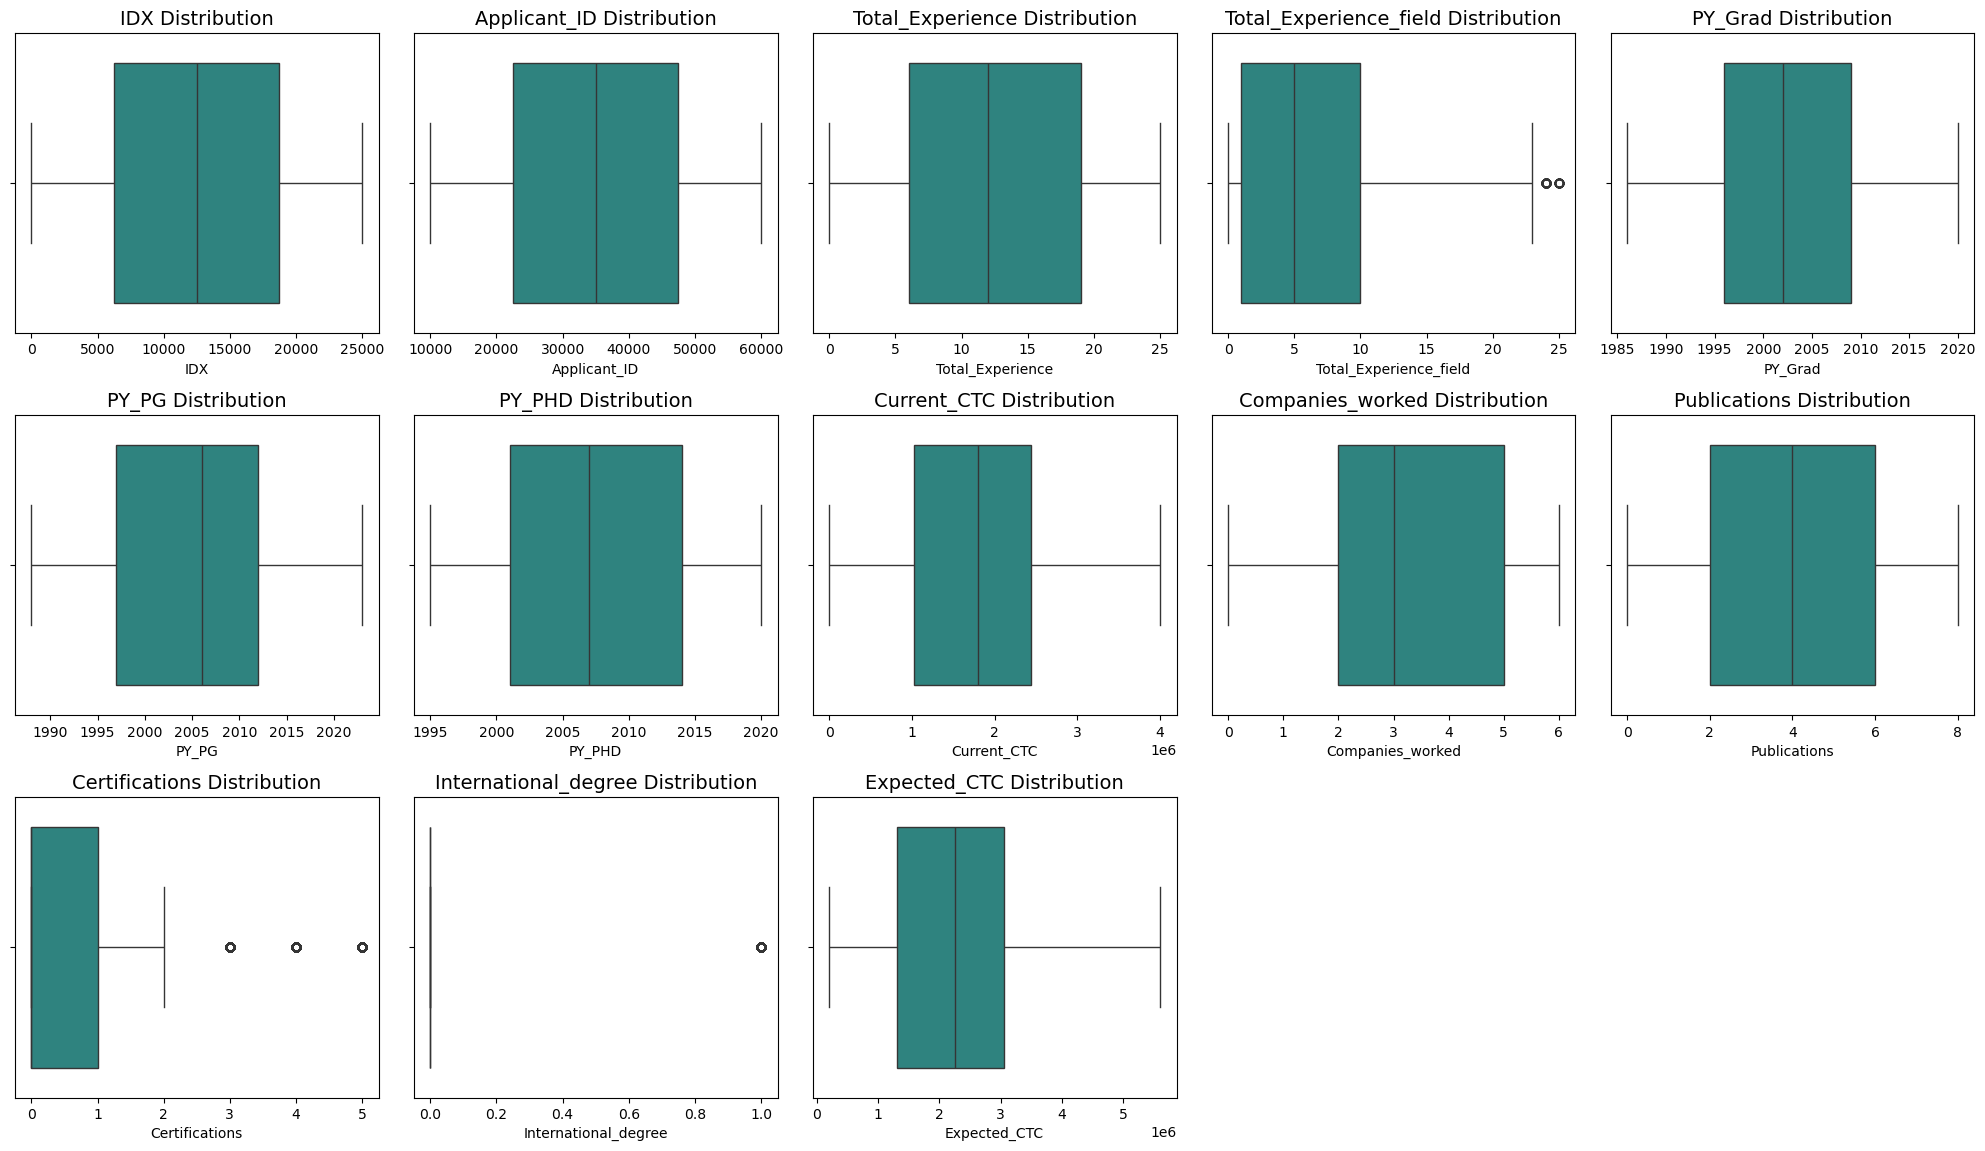

In [15]:
hr_nums = hr.select_dtypes(["int64", "float64"])

# Create subplots
num_features = len(hr_nums.columns)
rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))

# Flatten the axes for easier indexing
axes = axes.flatten()

# Iterate over each numerical column and plot
for i, num in enumerate(hr_nums.columns):
    sns.boxplot(data=hr_nums, x=num, palette="viridis", ax=axes[i])
    axes[i].set_title(f"{num} Distribution", fontsize=14)
    axes[i].set_xlabel(num)
    axes[i].set_ylabel("") 

# Remove empty subplots (if any)
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [16]:
hr["International_degree"]=hr["International_degree"].astype("object")
hr["Certifications"]=hr["Certifications"].astype("object")
hr["Companies_worked"]=hr["Companies_worked"].astype("object")
hr["Publications"]=hr["Publications"].astype("object")

Univariate Analysis - Categorical Features

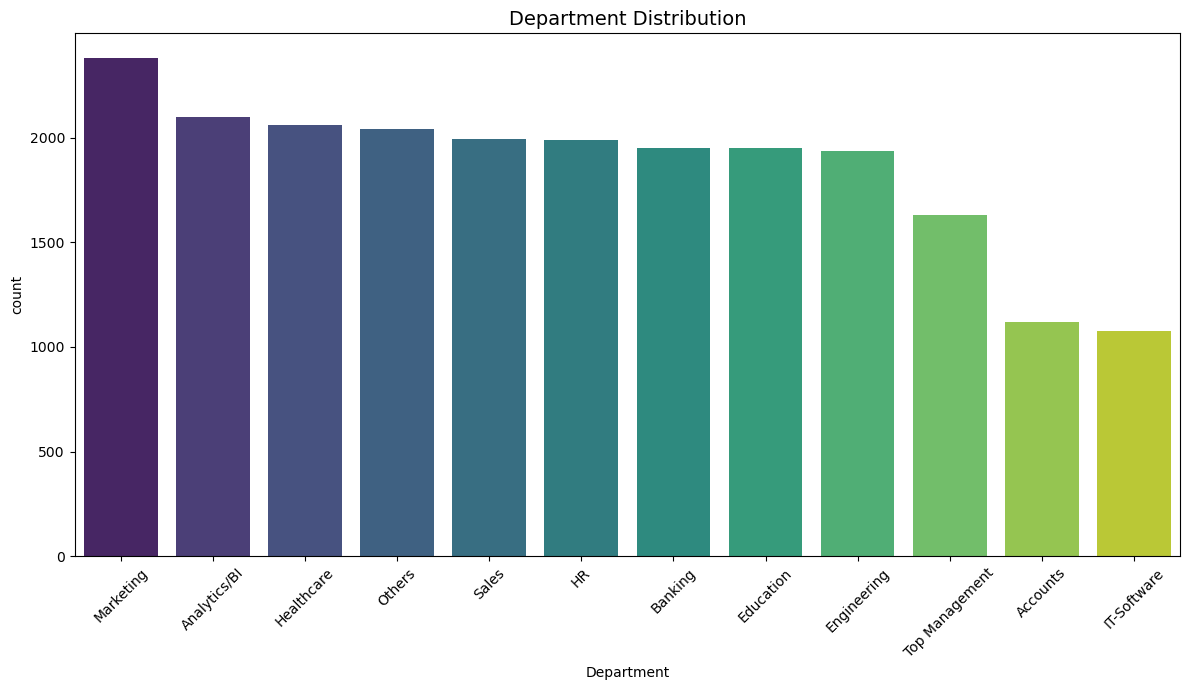

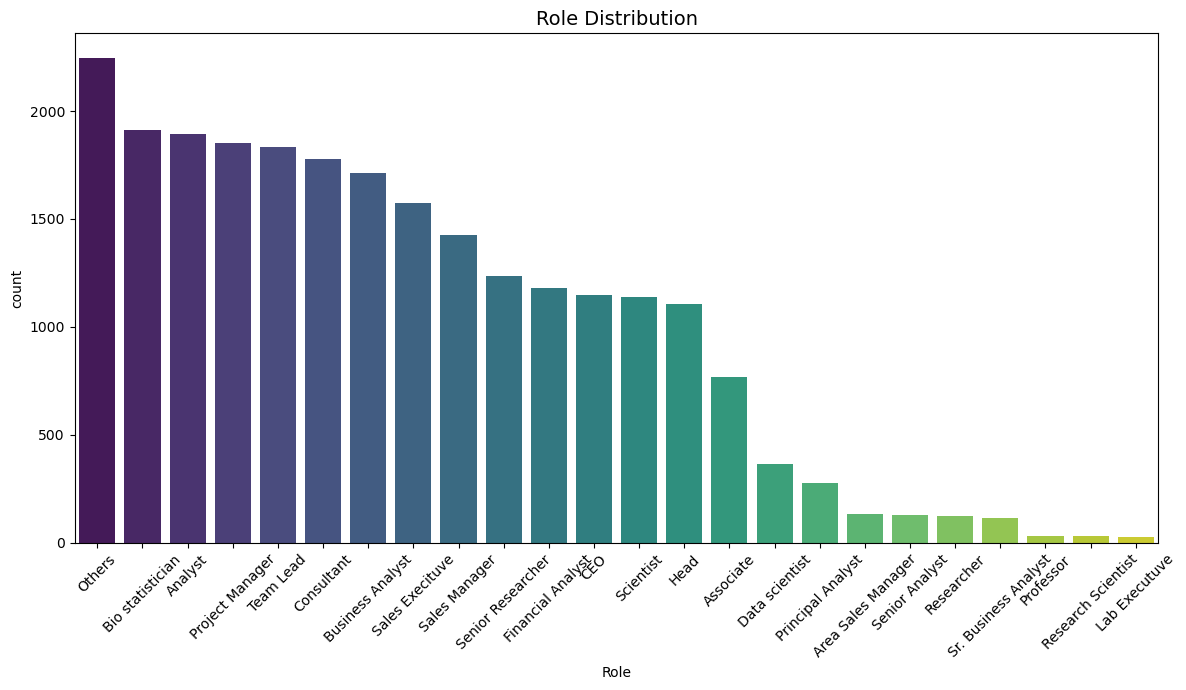

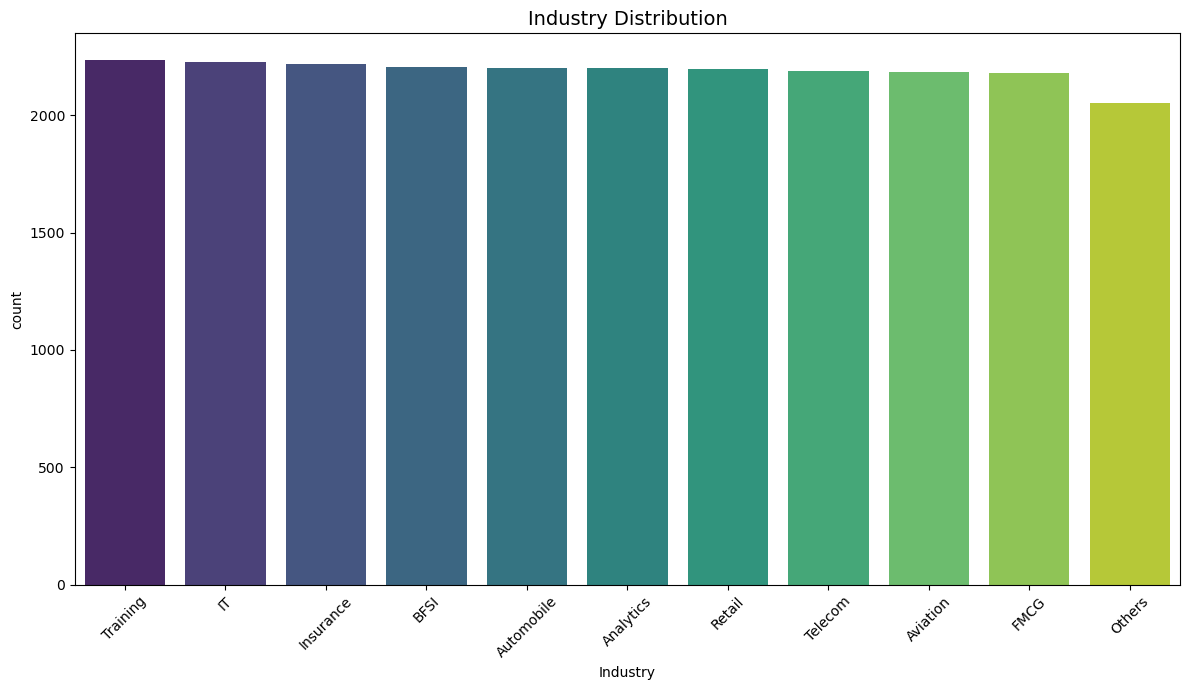

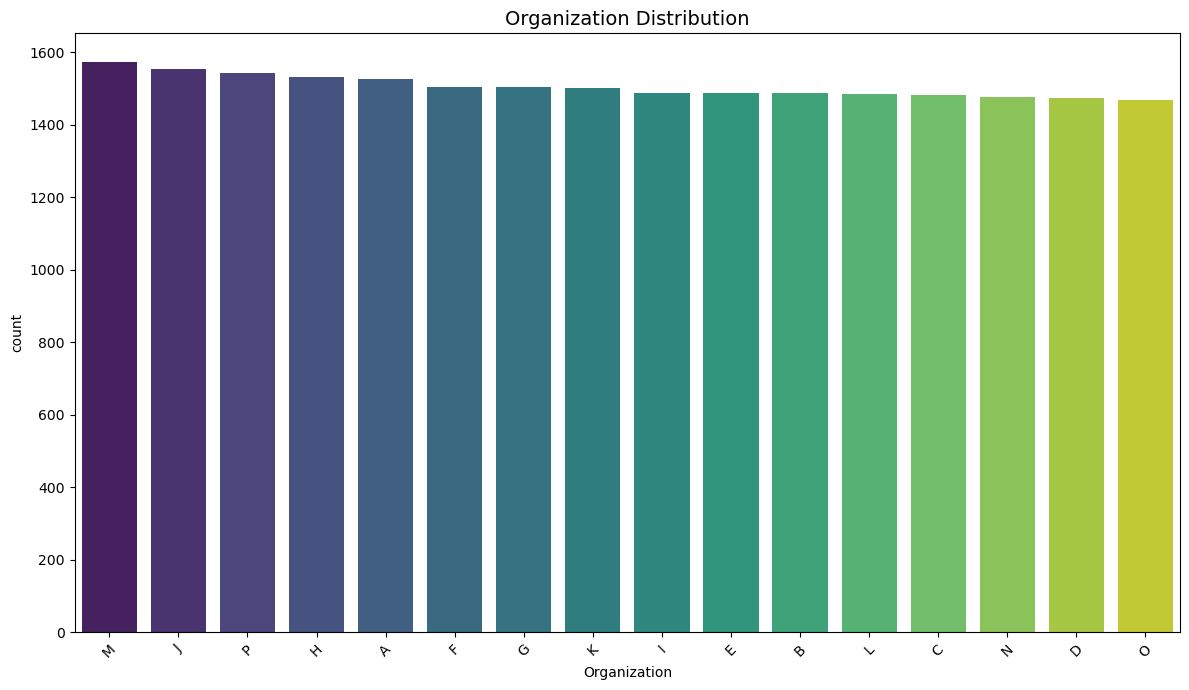

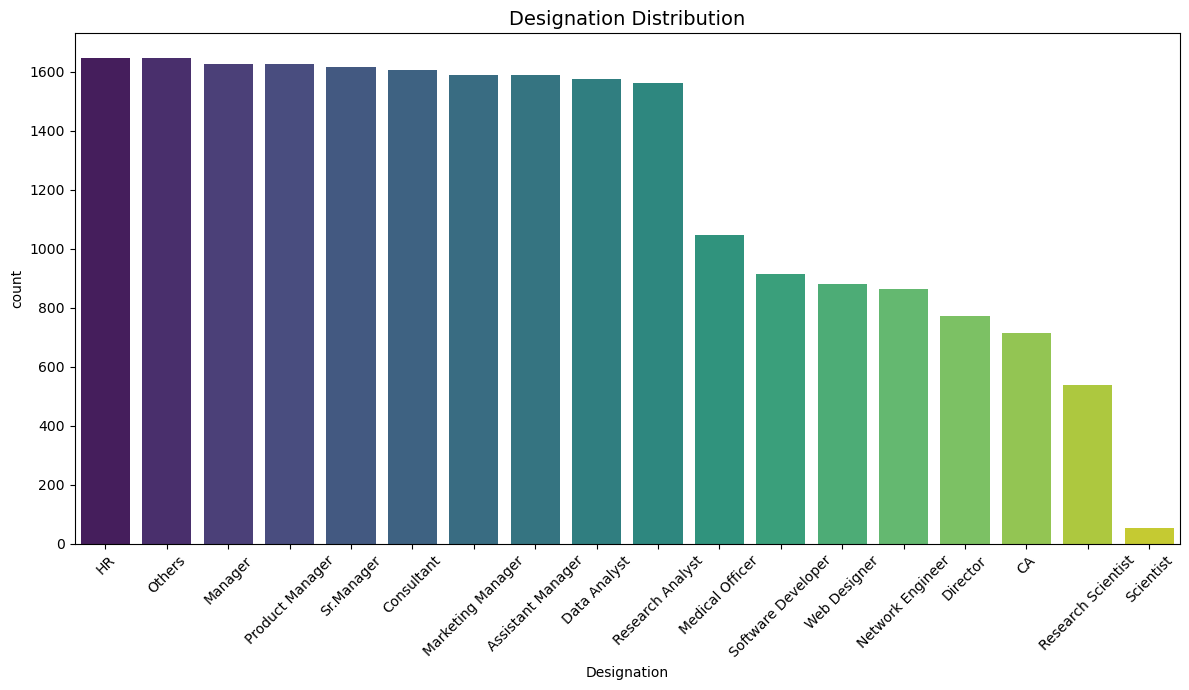

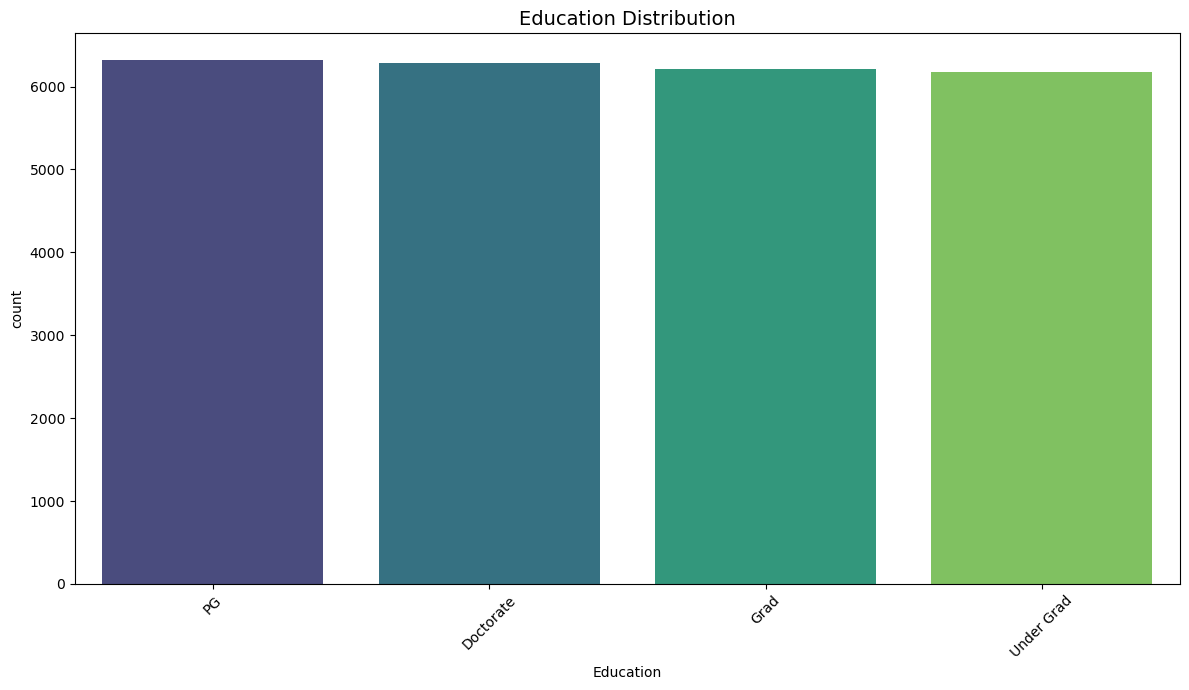

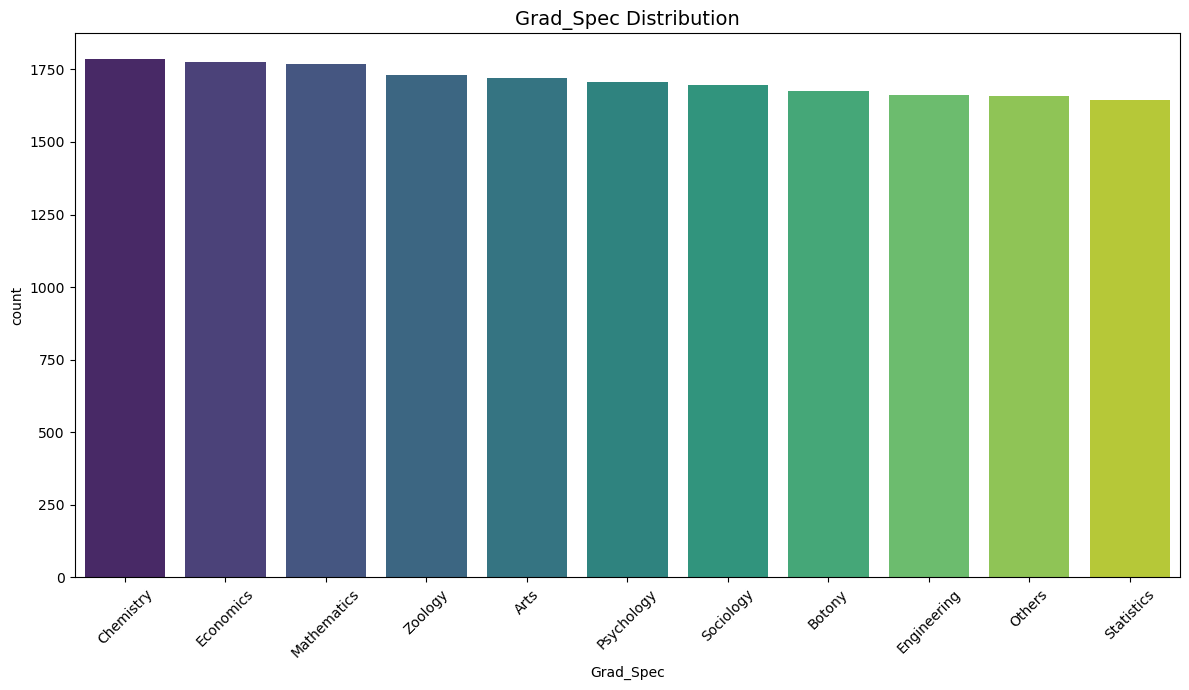

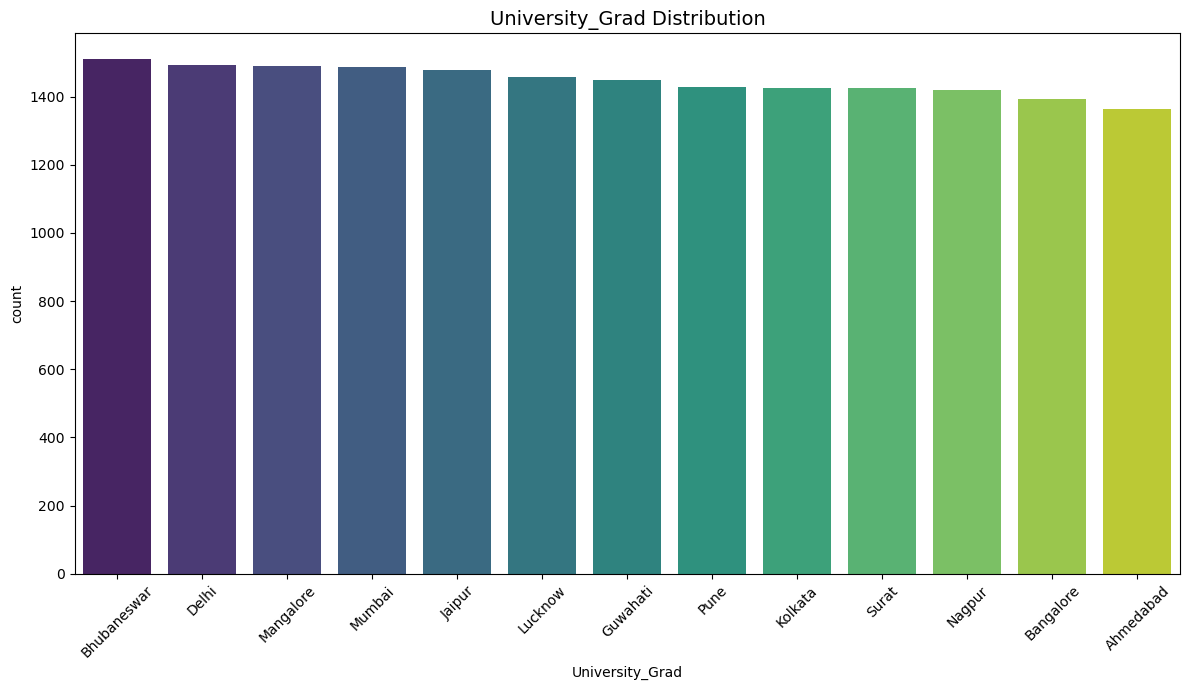

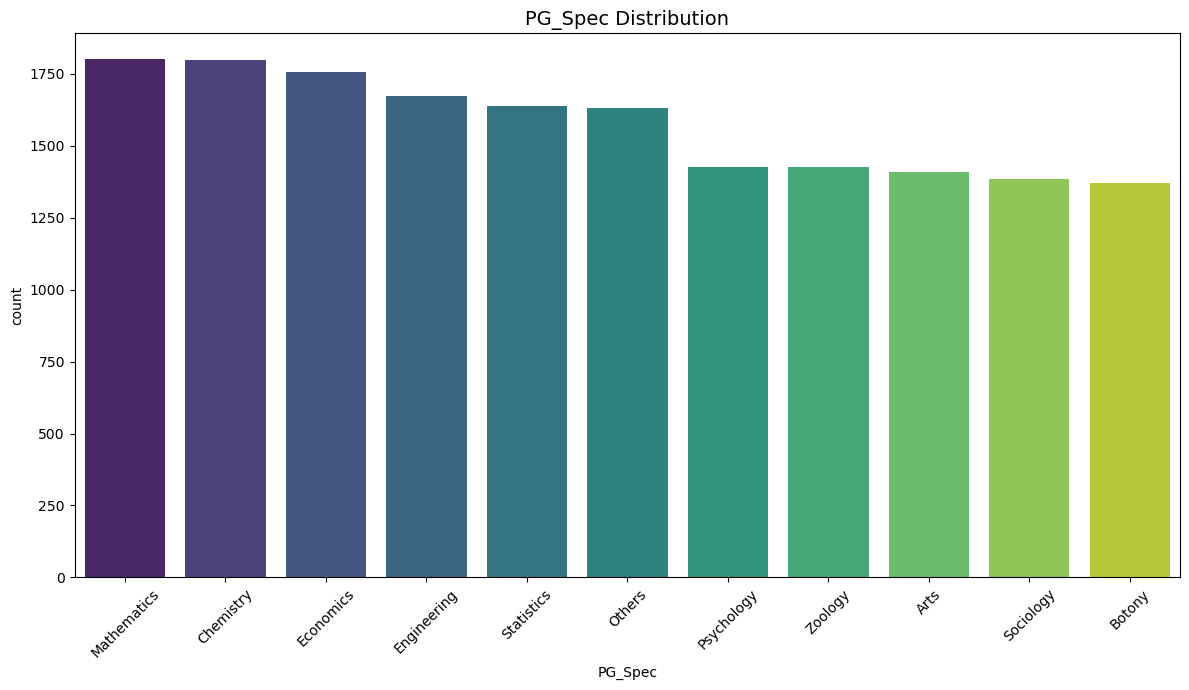

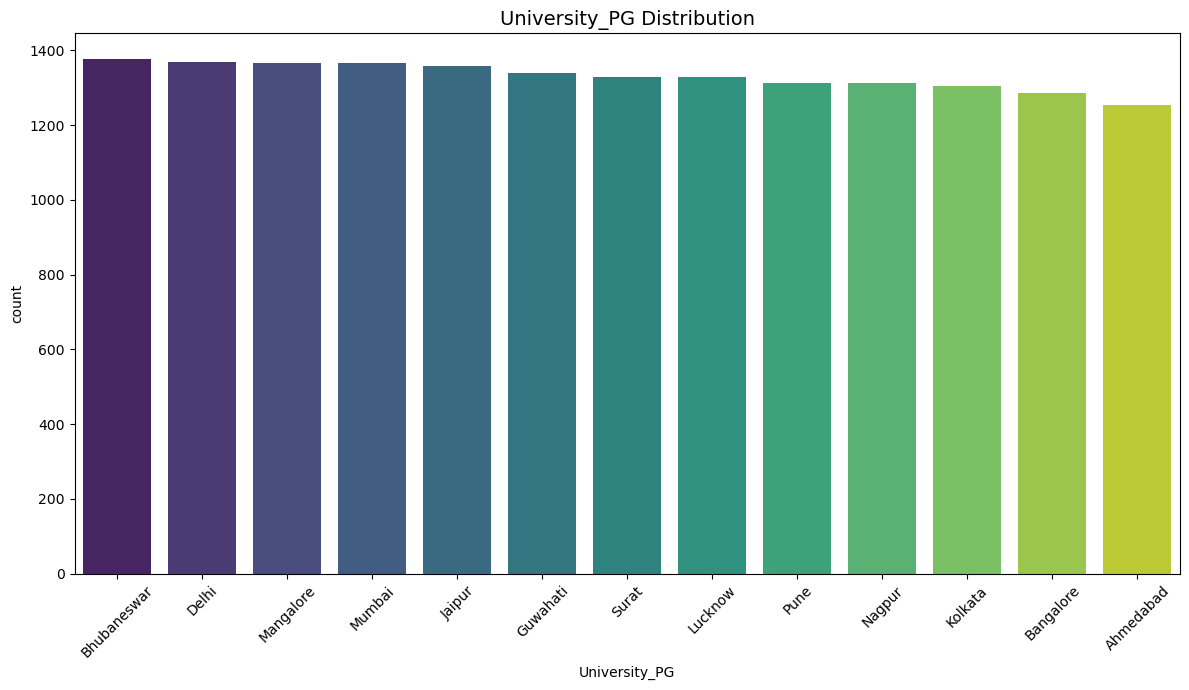

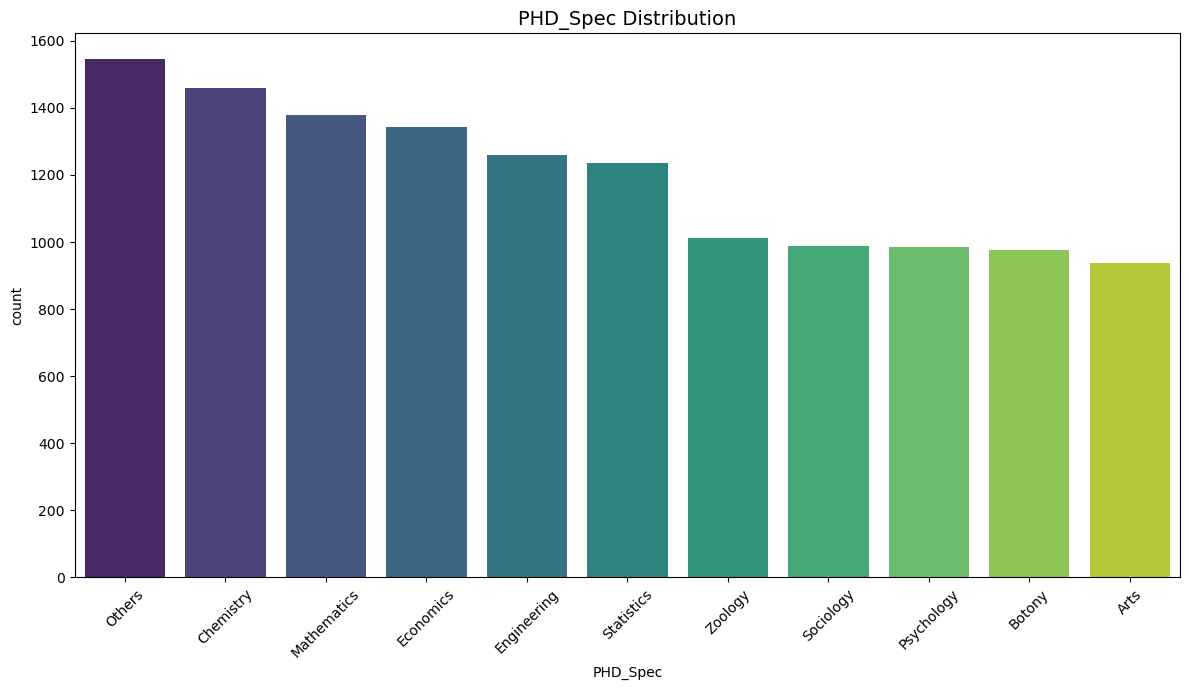

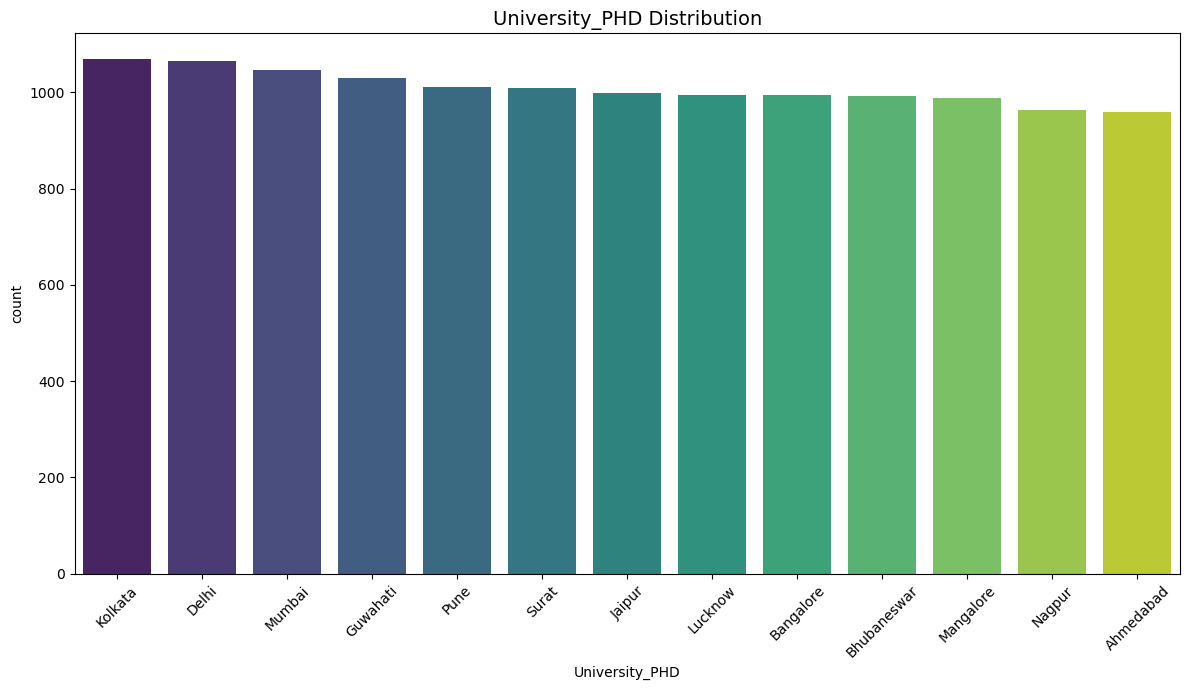

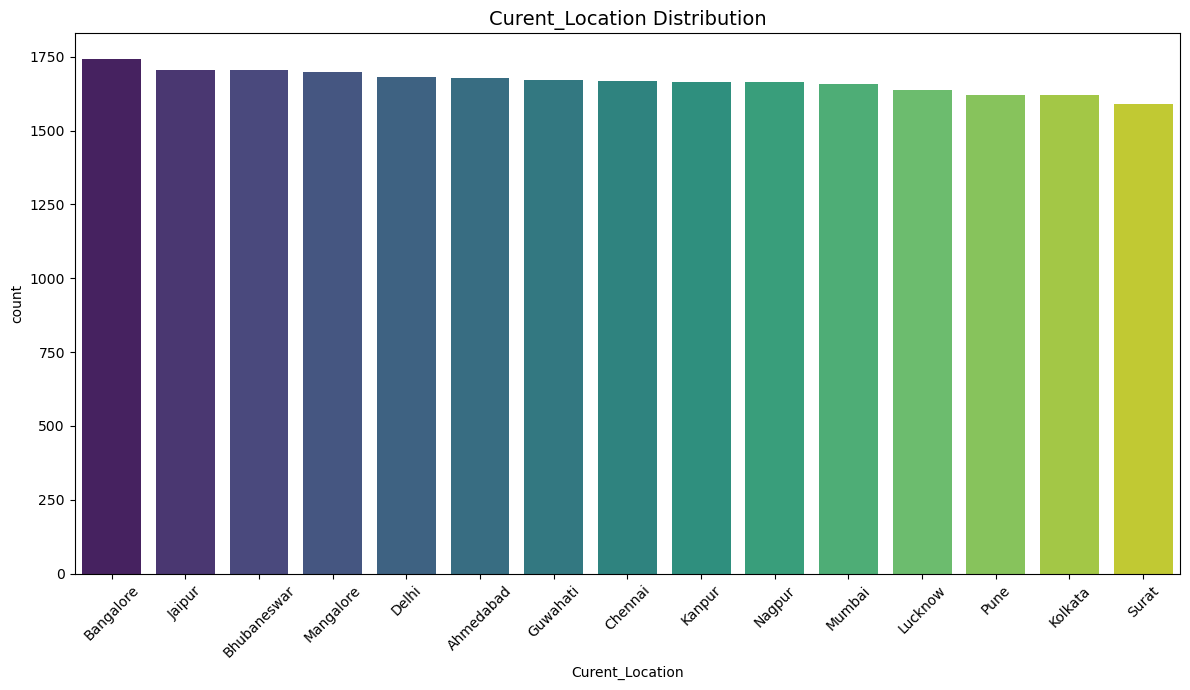

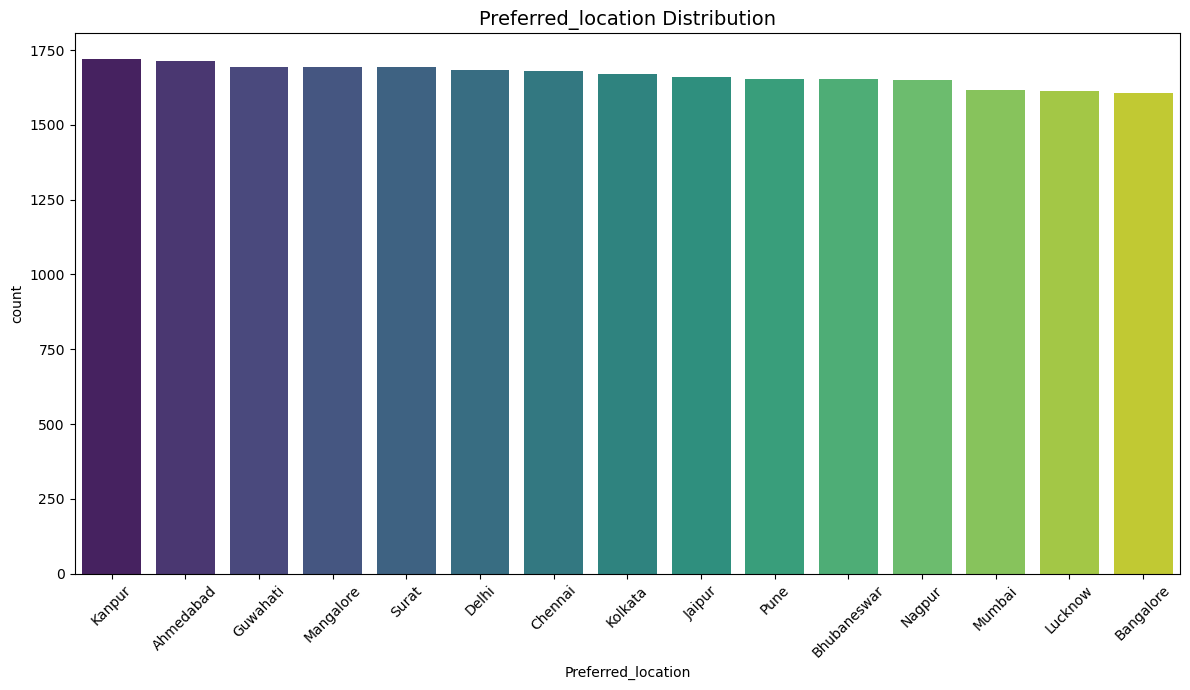

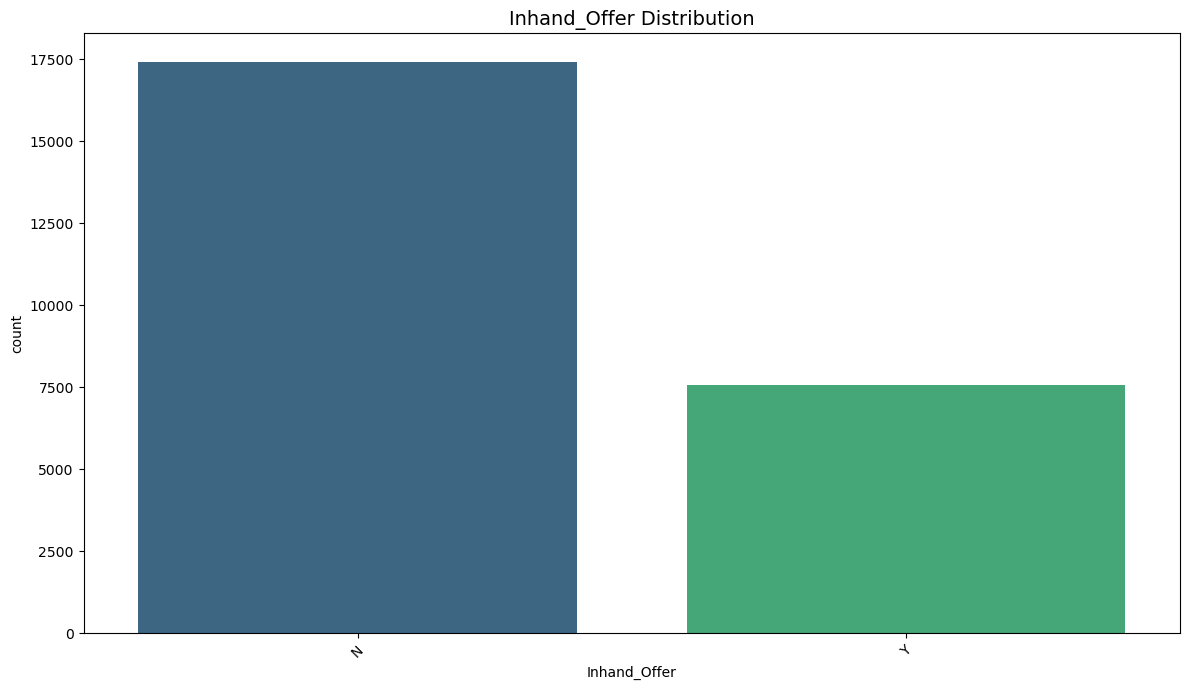

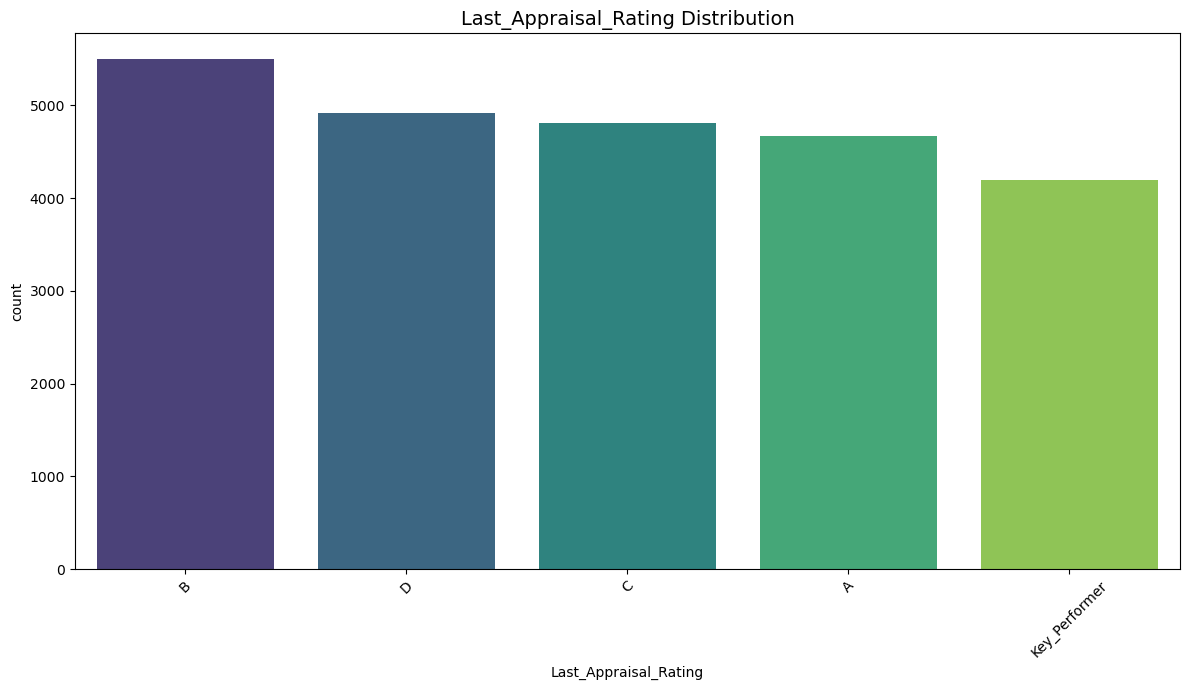

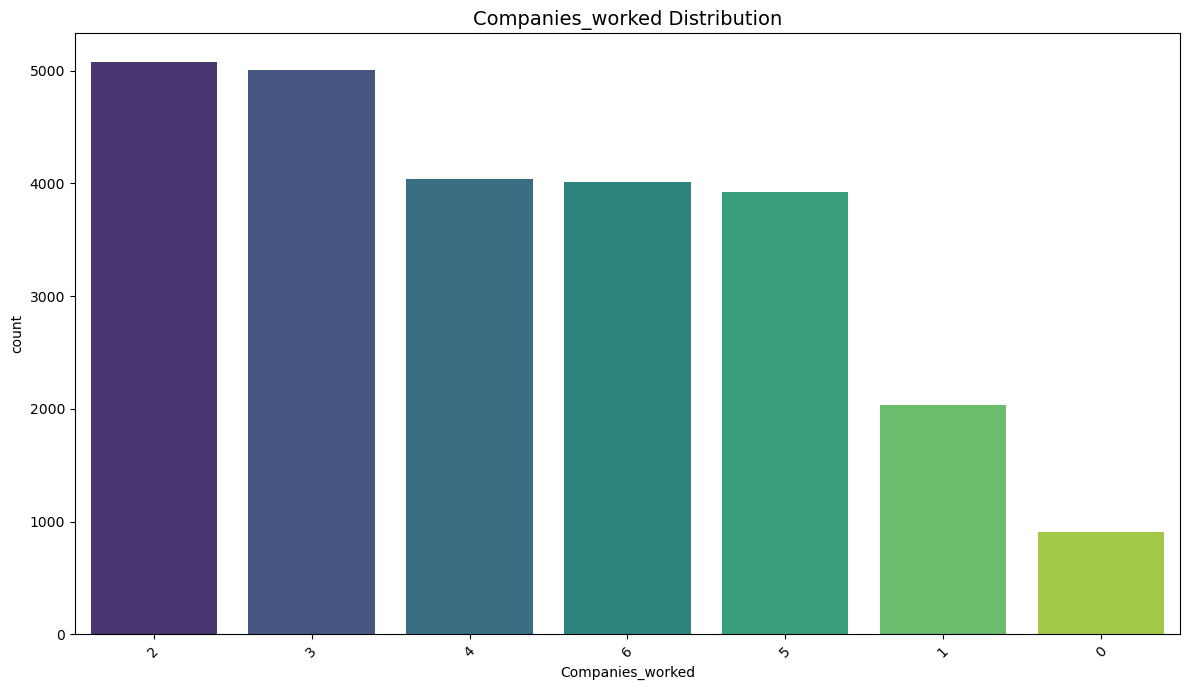

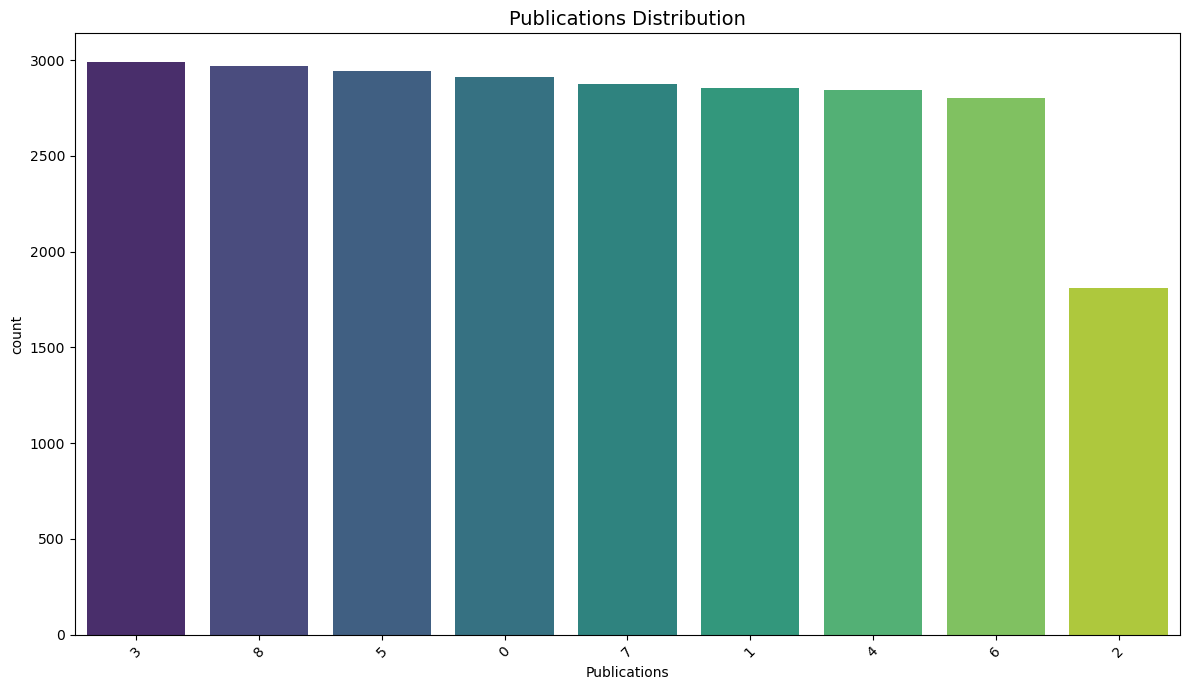

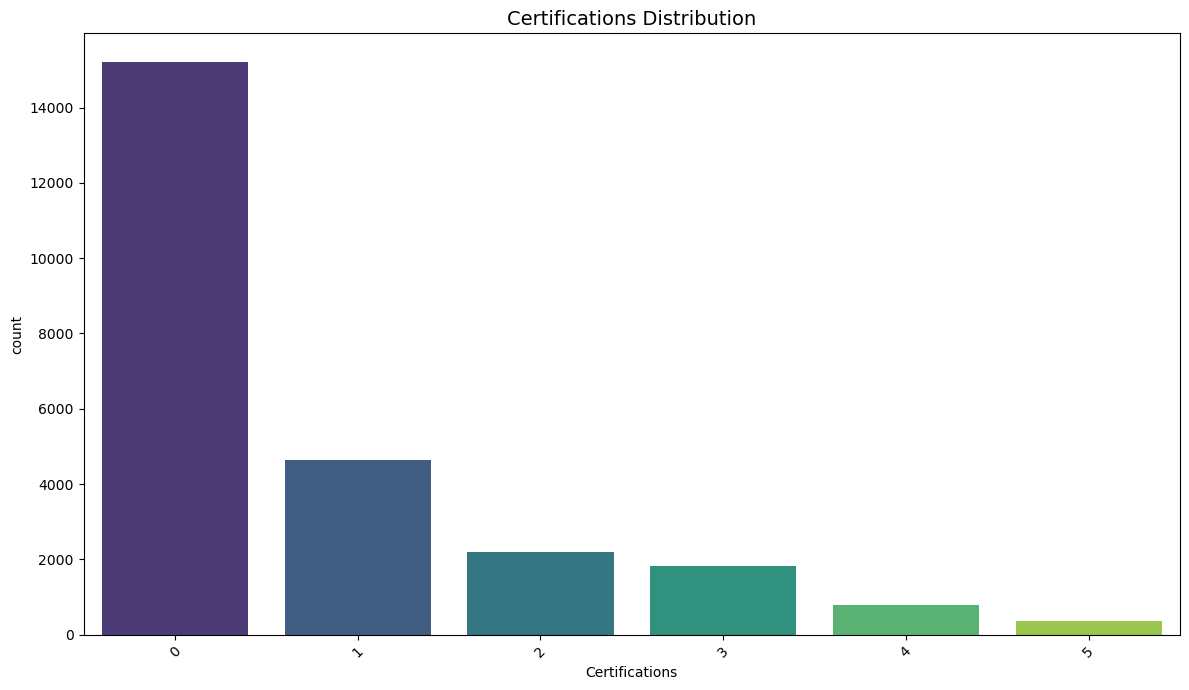

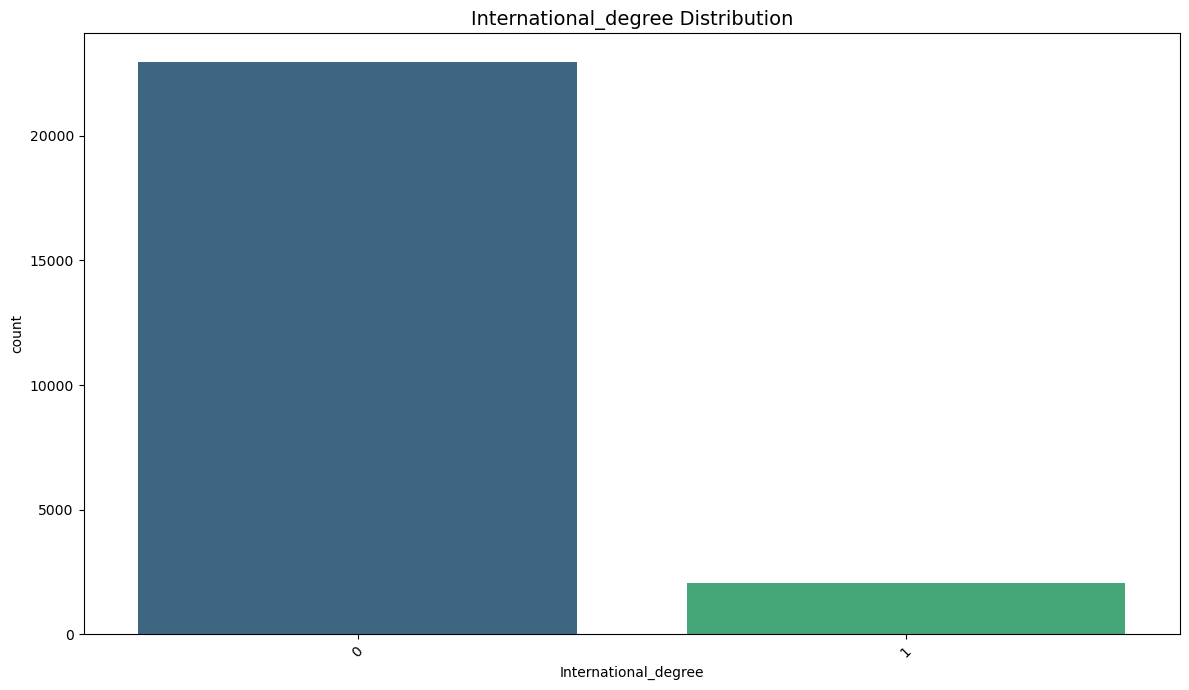

In [18]:
hr_cats = hr.select_dtypes(["object"])

# Iterate over each categorical column and plot
for i, cat in enumerate(hr_cats.columns):
    plt.figure(figsize=(12, 7))  # Create a new figure for each plot
    sns.countplot(data=hr, x=cat, palette="viridis", order=hr[cat].value_counts().index)
    plt.title(f"{cat} Distribution", fontsize=14)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust spacing for the current figure
    plt.show()

Bivariate Analysis - Categorical variables vs Target (Expected CTC)

In [20]:
def bivariate_cat(data, target):
    # Select categorical columns
    data_cats = data.select_dtypes(["object"])
    
    # Number of categorical features
    num_features = len(data_cats.columns)
    
    # Set up the grid of subplots
    fig, axes = plt.subplots(
        nrows=(num_features + 1) // 2,  # Calculate rows dynamically
        ncols=2,  # Set columns to 2
        figsize=(16, 5 * ((num_features + 1) // 2))  # Adjust figure size
    )
    
    # Flatten the axes for easier iteration
    axes = axes.flatten()
    
    # Iterate through each categorical feature
    for idx, feature in enumerate(data_cats.columns):
        # Determine the order based on the median of the target variable
        order = data.groupby(feature)[target].median().sort_values(ascending=False).index
        
        # Create a boxplot on the respective subplot
        sns.boxplot(
            data=data, x=feature, y=target,
            palette="viridis", order=order, ax=axes[idx]
        )
        
        # Rotate x-axis labels for better readability
        axes[idx].tick_params(axis='x', rotation=45)
        
        # Add title to the subplot
        axes[idx].set_title(f'{feature} vs {target} Distribution', fontsize=14)
    
    # Remove unused axes if there are any
    for idx in range(len(data_cats.columns), len(axes)):
        fig.delaxes(axes[idx])
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

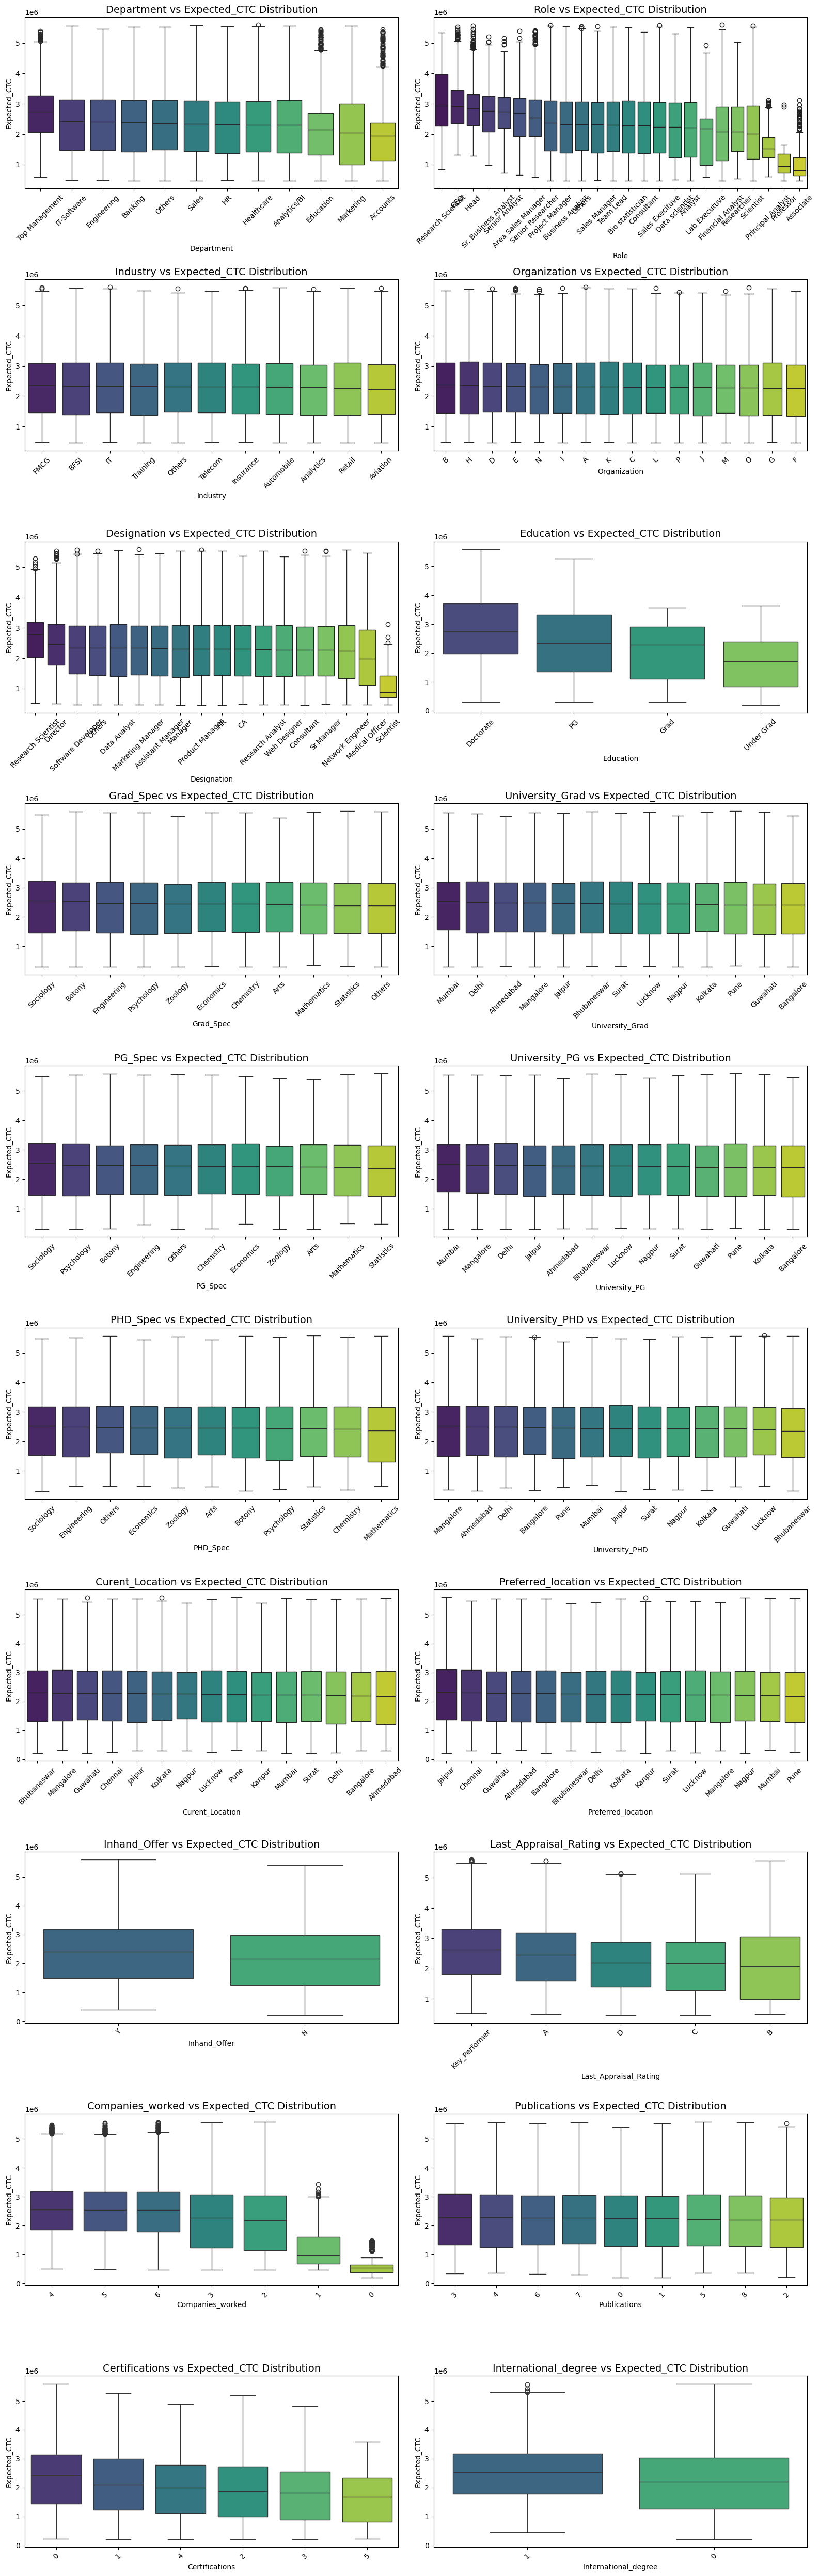

In [21]:
bivariate_cat(hr,target="Expected_CTC")

BiVariate Analysis - Numerical and Target 

In [23]:
def bivariate_num(data, target):
    # Select numerical columns
    data_nums = data.select_dtypes(["int64", "float64"]).drop(["IDX","Applicant_ID" ,"Expected_CTC"],axis=1)
    num_features = len(data_nums.columns)
    
    # Set up the grid of subplots
    fig, axes = plt.subplots(
        nrows=(num_features + 1) // 2,  # Calculate rows dynamically
        ncols=2,  # Set columns to 2
        figsize=(16, 5 * ((num_features + 1) // 2))  # Adjust figure size
    )
    
    # Flatten the axes for easier iteration
    axes = axes.flatten()
    
    # Iterate through each numerical feature
    for idx, feature in enumerate(data_nums.columns):
        # Create a regression plot on the respective subplot
        sns.regplot(
            x=data[feature], y=data[target], 
            scatter_kws={'color': 'blue'}, line_kws={'color': 'red'}, ax=axes[idx]
        )
      
    
    # Number of numerical features
        # Add title to the subplot
        axes[idx].set_title(f'{feature} vs {target} Distribution', fontsize=14)
        
        # Rotate x-axis labels for better readability
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Remove unused axes if there are any
    for idx in range(len(data_nums.columns), len(axes)):
        fig.delaxes(axes[idx])
    
    # Adjust layout
    plt.tight_layout()
    plt.show()


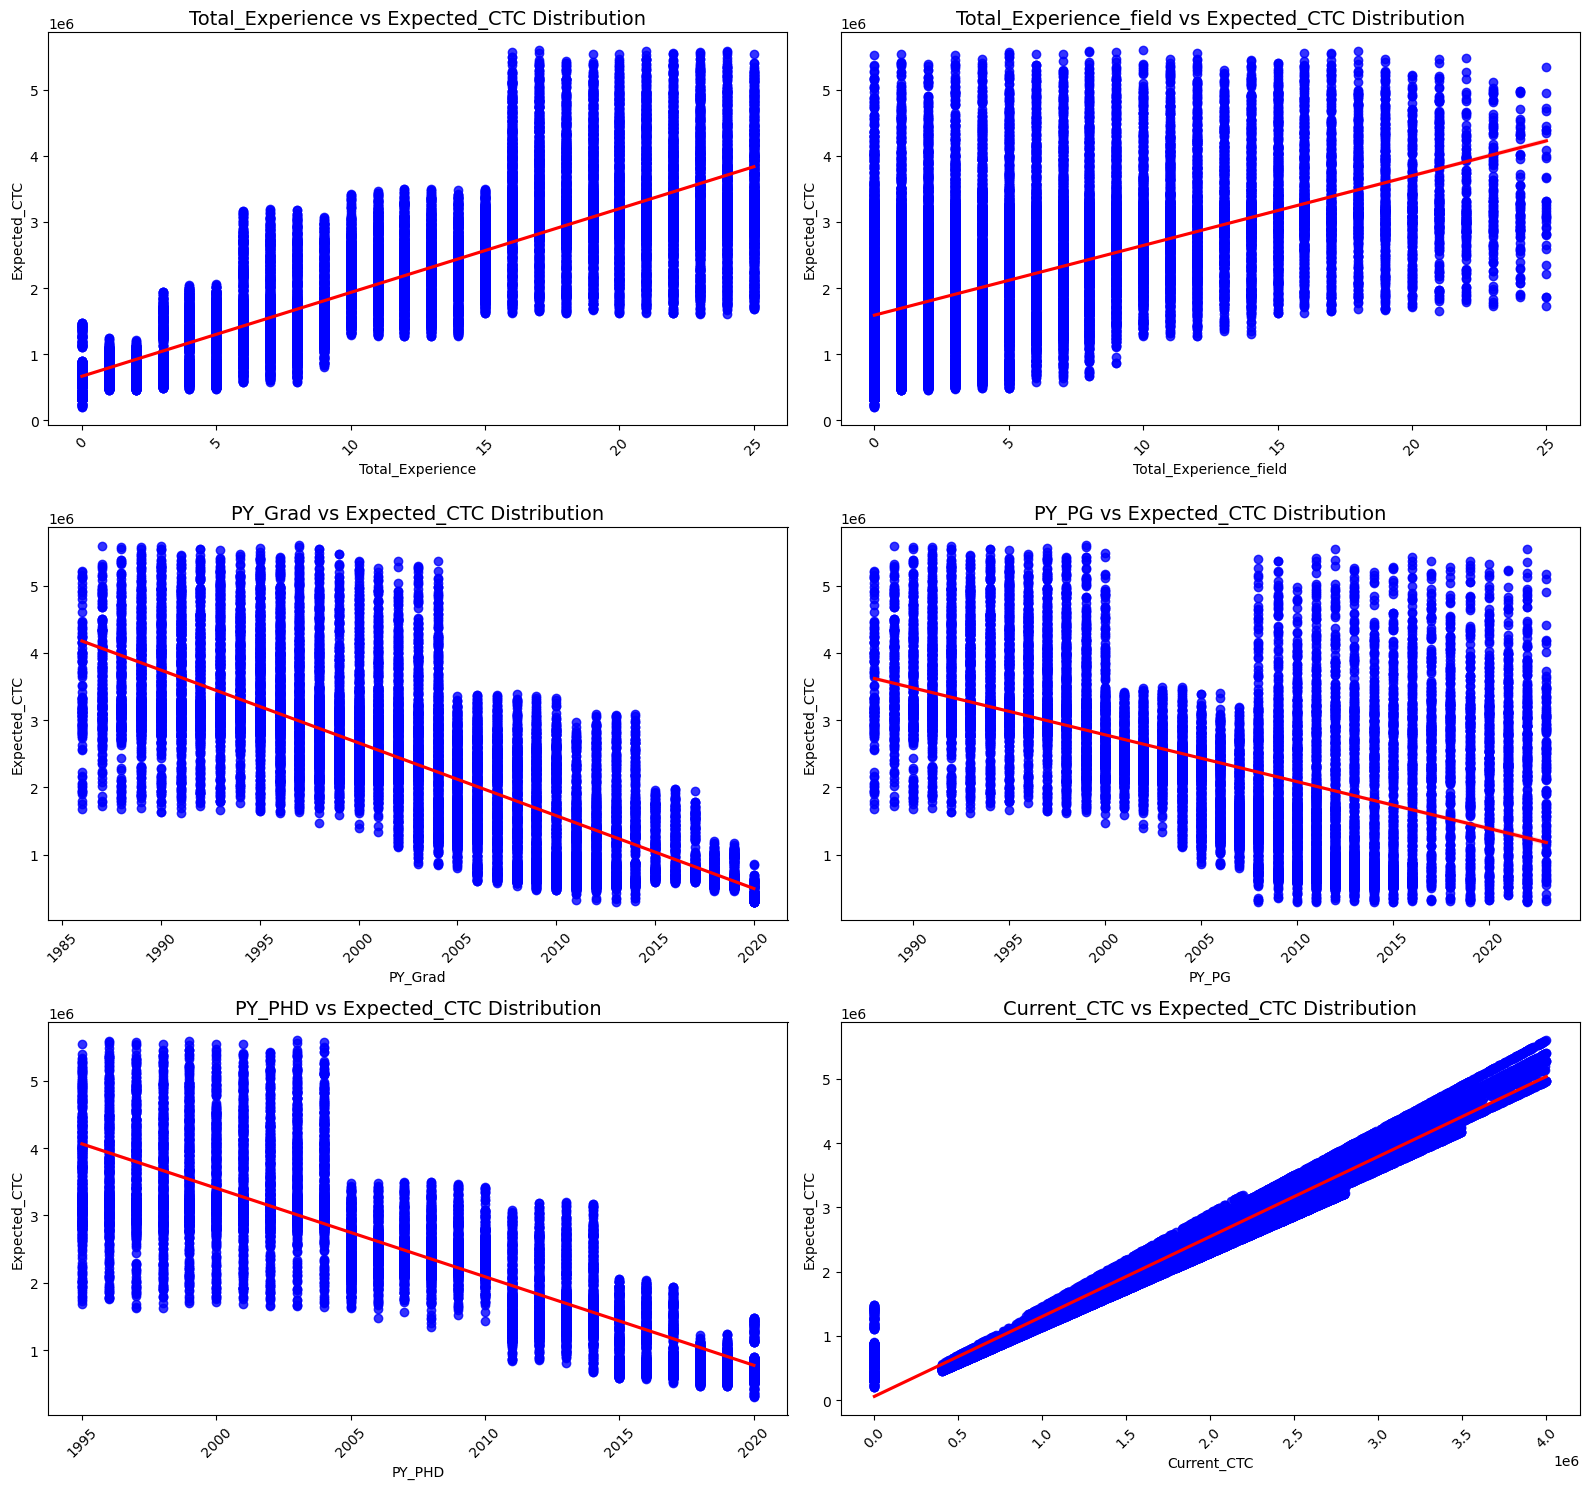

In [24]:
bivariate_num(hr,target="Expected_CTC")

Multivariate Analysis

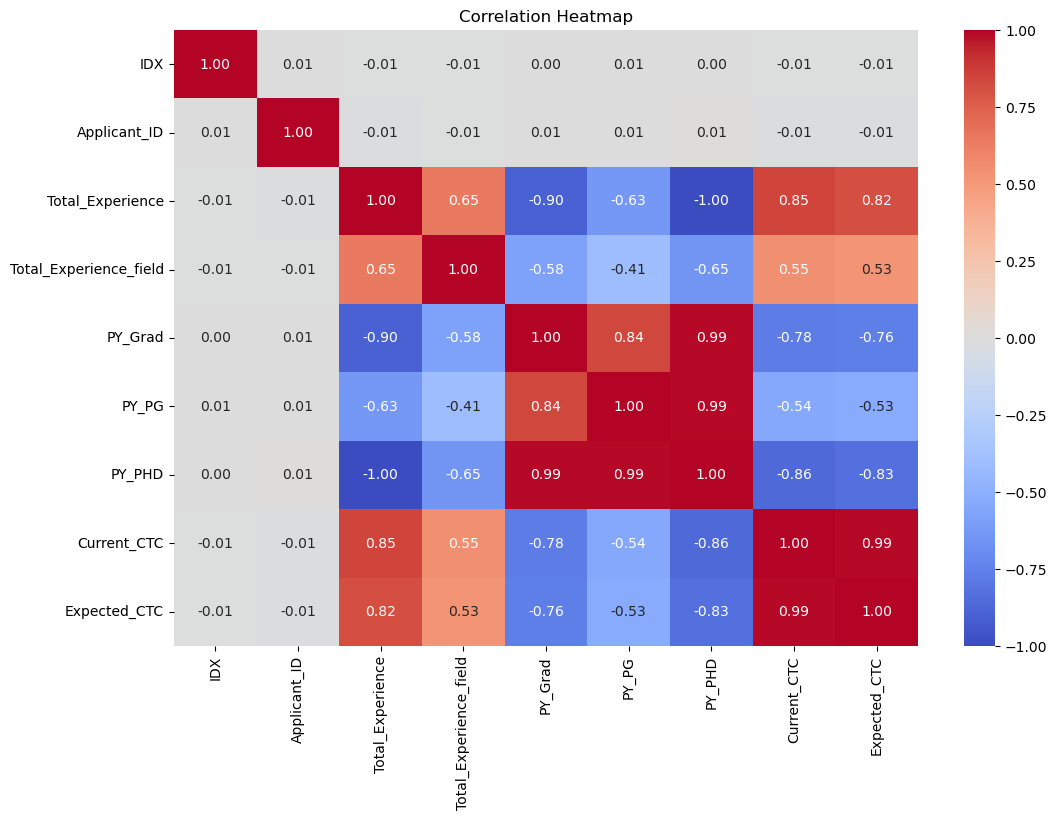

In [26]:
hr_nums = hr.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = hr_nums.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

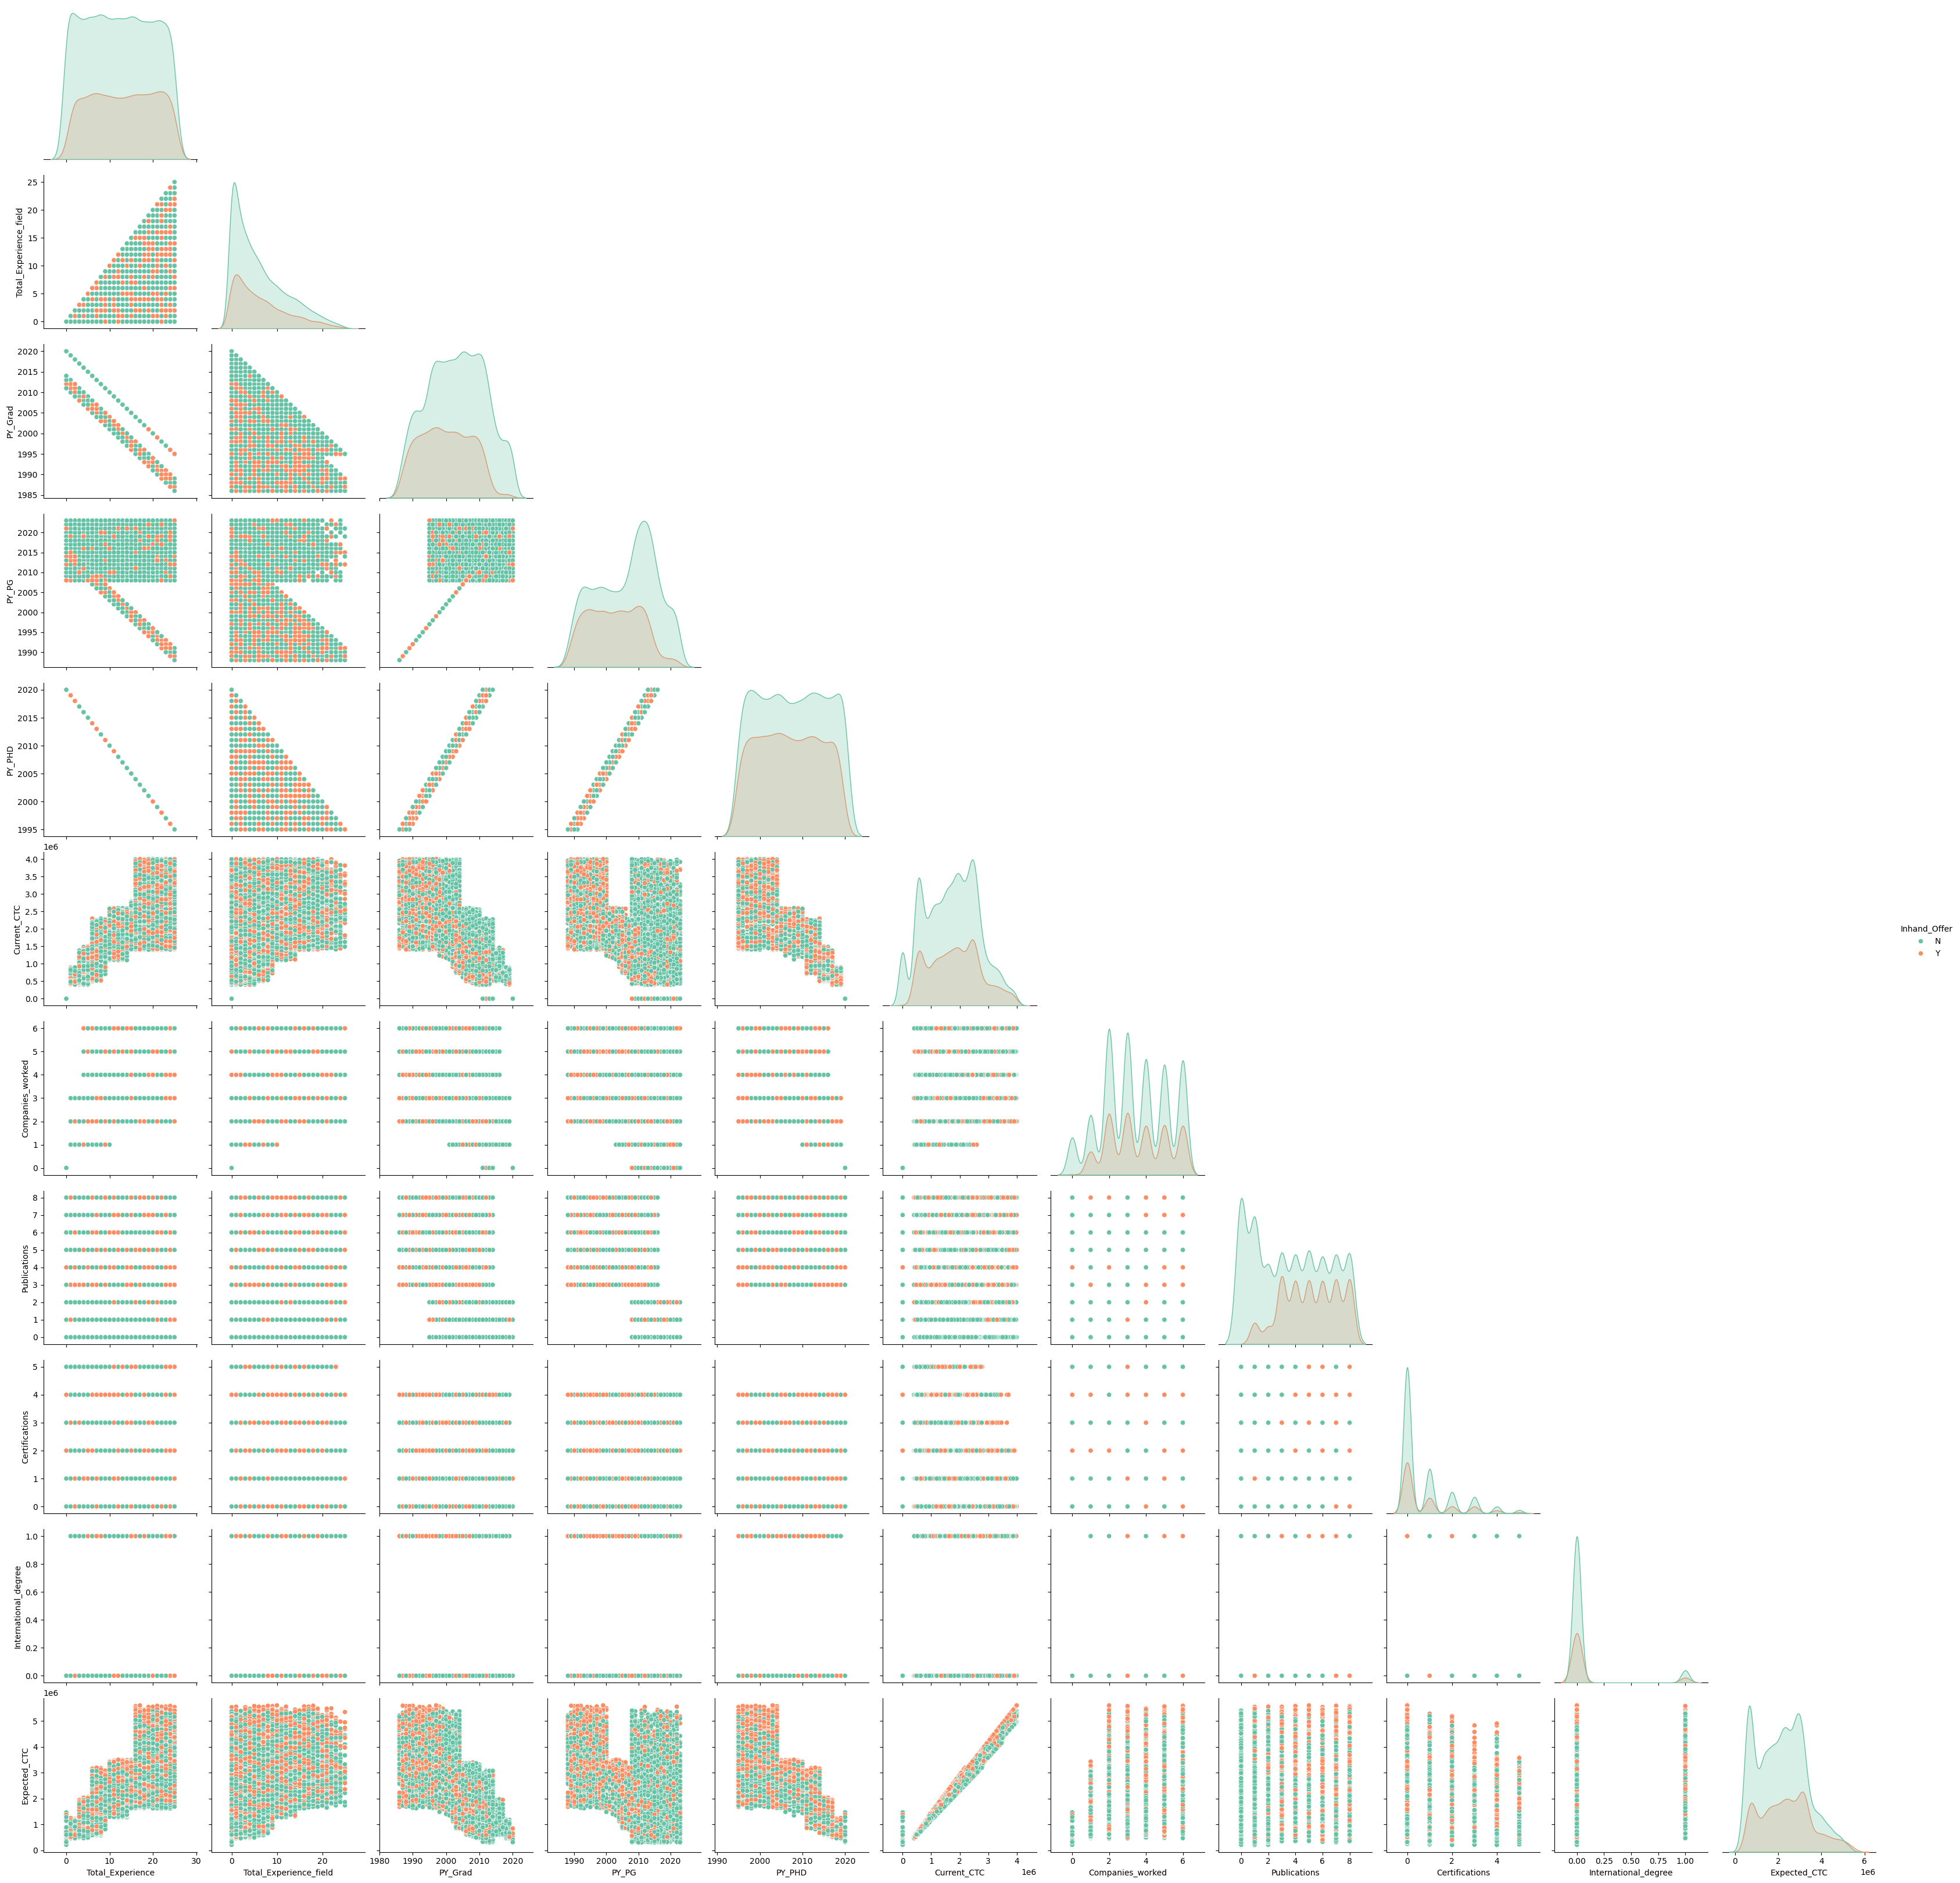

In [27]:
import seaborn as sns

sns.pairplot(data=hr.drop(["IDX", "Applicant_ID"], axis=1),
             hue="Inhand_Offer",  # Directly reference the column name for hue
             palette="Set2",
             diag_kind="kde",  # Kernel Density Estimation for diagonal plots
             height=3,  # Size of the individual subplots, adjusted for better visual clarity
             corner=True)  # Avoid plotting redundant upper triangle


Hypothesis Testing

Let's perform paired t-test to check if there is any significant difference between current CTC and expected CTC

t-test Assumptions:
Null Hypothesis: There is no significant difference between current and Expected for the same set of applicants
Alternate Hypothesis: There is a difference between

Let's perform Shaipro Test to check if the distribution of the difference is normal or not, which is the pre-condition for t-test.

Shapiro Test Assumptions:
Null Hypothesis: Difference between Current and Expect CTC is normally distributed
Alternate: It is not normally distributed.

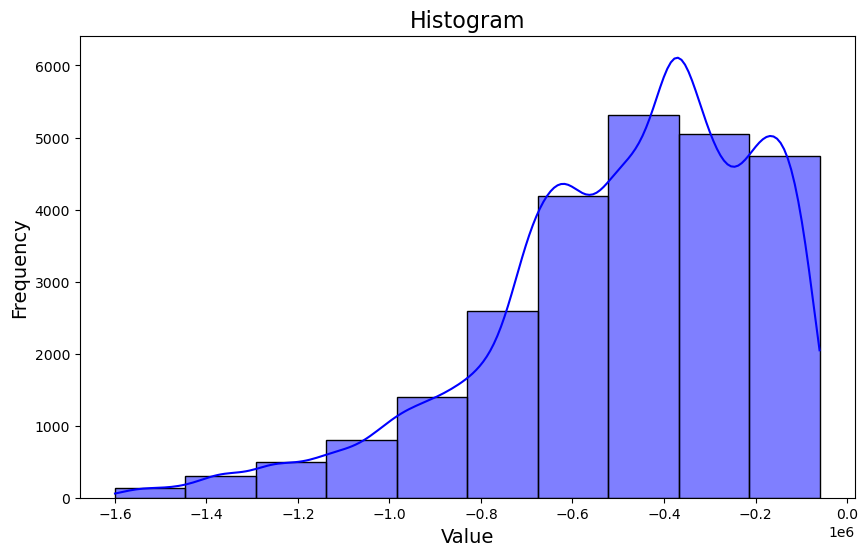

In [30]:
differences = hr["Current_CTC"]-hr["Expected_CTC"]
plt.figure(figsize=(10, 6))  # Set the figure size
sns.histplot(differences, bins=10, kde=True, color='blue')  # Add KDE (kernel density estimate) if needed
plt.title('Histogram', fontsize=16)
plt.xlabel('Value', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

In [31]:
from scipy.stats import shapiro

# Calculate differences


# Perform Shapiro-Wilk test for normality
stat, p = shapiro(differences)
print(f"Shapiro-Wilk Test: p = {p:.3f}")
if p < 0.05:
    print("Differences are not normally distributed.")
else:
    print("Differences are normally distributed.")

Shapiro-Wilk Test: p = 0.000
Differences are not normally distributed.


As the difference is not normally distributed we will perform wilcoxon test to check if the difference is significant or not

In [33]:
from scipy.stats import wilcoxon

# Perform Wilcoxon Signed-Rank Test
stat, p_value = wilcoxon(hr["Current_CTC"], hr["Expected_CTC"])

# Output Results
print(f"Wilcoxon Statistic: {stat}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("The difference is statistically significant (p < 0.05).")
else:
    print("The difference is not statistically significant (p >= 0.05).")

Wilcoxon Statistic: 0.0
P-value: 0.000
The difference is statistically significant (p < 0.05).


We see that there is a significant difference between current ctc and expected ctc. This may happen bcoz of so many 
different reasons. We will analyze this gradually.

Let's check if each individual categorical features has an impact on Expected CTC or not

Null Hypothesis: There is no significant impact
Alternate: There is impact.

In [36]:
from scipy.stats import f_oneway
def check_impact_ANOVA (data, target):
    pvalues=[]
    cats=data.select_dtypes("object").columns
    for feature in cats:
        data_cleaned = data.dropna(subset=[feature, target])
        group_sizes = data_cleaned.groupby(feature)[target].size()
        
        
        # Filter out groups with fewer than 2 observations
        valid_groups = group_sizes[group_sizes >= 2].index
        data_filtered = data_cleaned[data_cleaned[feature].isin(valid_groups)]
        
        values = data_filtered[feature].unique()
        groups = [data_filtered[data_filtered[feature] == category][target] for category in values]
        f_statistic, p_value = f_oneway(*groups)
        row = {"Category": feature, "p-value": round(p_value,2)}
        pvalues.append(row)

    return pd.DataFrame(pvalues)       

In [37]:
check_impact_ANOVA(hr,target='Expected_CTC')

,Category,p-value
0,Department,0.00
1,Role,0.00
2,Industry,0.18
3,Organization,0.28
4,Designation,0.00
5,Education,0.00
6,Grad_Spec,0.75
7,University_Grad,0.84
8,PG_Spec,0.55
9,University_PG,0.87


As per the visualization as well as Hypothesis Testing, we can conclude that Department, Role, Designation, Education, 
Inhand Offer, Last Appraisal Rating, No of Companies Worked, Certifications and International Degree individually have 
significant impact on the Expected CTC.

Let's check if industry and organization jointly has an impact or not

In [40]:
#Method 2 of drawing an interaction plot
from statsmodels.formula.api import ols      # For n-way ANOVA
from statsmodels.stats.anova import _get_covariance,anova_lm # For n-way ANOVA
formula = 'Expected_CTC ~ C(Industry) + C(Organization) + C(Industry):C(Organization)'
model = ols(formula, hr).fit()
aov_table = anova_lm(model)
print(aov_table)

                                  df        sum_sq       mean_sq         F  \
C(Industry)                     10.0  1.779303e+13  1.779303e+12  1.384359   
C(Organization)                 15.0  2.212775e+13  1.475183e+12  1.147743   
C(Industry):C(Organization)    150.0  2.006278e+14  1.337519e+12  1.040635   
Residual                     23916.0  3.073901e+16  1.285291e+12       NaN   

                               PR(>F)  
C(Industry)                  0.180326  
C(Organization)              0.306197  
C(Industry):C(Organization)  0.350433  
Residual                          NaN  


p-value is greater than 0.3 which means there is no impact.

Let's check if Graduation_Specialization and University_Grad jointly has an impact or not

In [43]:
formula = 'Expected_CTC ~ C(Grad_Spec) + C(University_Grad) + C(Grad_Spec):C(University_Grad)'
model = ols(formula, hr).fit()
aov_table = anova_lm(model)
print(aov_table)

                                      df        sum_sq       mean_sq  \
C(Grad_Spec)                        10.0  9.437514e+12  9.437514e+11   
C(University_Grad)                  12.0  1.000353e+13  8.336277e+11   
C(Grad_Spec):C(University_Grad)    120.0  2.222338e+14  1.851948e+12   
Residual                         18677.0  2.622100e+16  1.403919e+12   

                                        F    PR(>F)  
C(Grad_Spec)                     0.672226  0.751358  
C(University_Grad)               0.593786  0.849177  
C(Grad_Spec):C(University_Grad)  1.319128  0.011243  
Residual                              NaN       NaN  


p-value is less than 0.05 which means there is an impact.

Let's check if PG_Specialization and University_PG jointly has an impact or not

In [46]:
formula = 'Expected_CTC ~ C(PG_Spec) + C(University_PG) + C(PG_Spec):C(University_PG)'
model = ols(formula, hr).fit()
aov_table = anova_lm(model)
print(aov_table)

                                  df        sum_sq       mean_sq         F  \
C(PG_Spec)                      10.0  1.237396e+13  1.237396e+12  0.884667   
C(University_PG)                12.0  9.405597e+12  7.837998e+11  0.560372   
C(PG_Spec):C(University_PG)    120.0  2.040057e+14  1.700047e+12  1.215436   
Residual                     17165.0  2.400893e+16  1.398714e+12       NaN   

                               PR(>F)  
C(PG_Spec)                   0.546735  
C(University_PG)             0.875233  
C(PG_Spec):C(University_PG)  0.055056  
Residual                          NaN  


p-value is close to 0.05 which means there is impact.

Let's check if Current CTC and Preferred Location jointly have an impact ont the Expected CTC or not

In [49]:
formula = 'Expected_CTC ~ (Current_CTC) + C(Preferred_location) + (Current_CTC):C(Preferred_location)'
model = ols(formula, hr).fit()
aov_table = anova_lm(model)
print(aov_table)

                                        df        sum_sq       mean_sq  \
C(Preferred_location)                 14.0  1.546245e+13  1.104461e+12   
Current_CTC                            1.0  3.276373e+16  3.276373e+16   
Current_CTC:C(Preferred_location)     14.0  1.192139e+12  8.515275e+10   
Residual                           24970.0  8.861241e+14  3.548755e+10   

                                               F        PR(>F)  
C(Preferred_location)                  31.122488  2.193618e-83  
Current_CTC                        923245.783329  0.000000e+00  
Current_CTC:C(Preferred_location)       2.399511  2.375649e-03  
Residual                                     NaN           NaN  


p-value is less than 0.05 which means there is an impact.

In [51]:
hr_null=(hr.isna().sum()/len(hr))*100
hr_null[hr_null.values>0].sort_values(ascending=False)

PHD_Spec                 47.524
University_PHD           47.524
PY_PHD                   47.524
PG_Spec                  30.768
University_PG            30.768
PY_PG                    30.768
Grad_Spec                24.720
University_Grad          24.720
PY_Grad                  24.720
Designation              12.516
Department               11.112
Role                      3.852
Industry                  3.632
Organization              3.632
Last_Appraisal_Rating     3.632
dtype: float64

As the missing values of PHD_Specialization, University_PHD, Passing_Year_Of_PHD, Passing Year of PG, Passing Year of Grad features contribute
significant missing data in the data set and also statistically not significant, we are removing these features along IDA and applicant_id

Removal of unwanted variables

In [54]:
hr_new=hr.drop(["IDX","Applicant_ID","PY_PHD","University_PHD","PHD_Spec","PY_Grad","PY_PG", "Organization", "Industry"], axis=1)

In [55]:
hr_others=hr_new[(hr_new["Department"]=='Others') & (hr_new["Role"]=='Others') & (hr_new["Designation"]=='Others')]
hr_others

,Total_Experience,Total_Experience_field,Department,Role,Designation,Education,Grad_Spec,University_Grad,PG_Spec,University_PG,Curent_Location,Preferred_location,Current_CTC,Inhand_Offer,Last_Appraisal_Rating,Companies_worked,Publications,Certifications,International_degree,Expected_CTC
199,22,22,Others,Others,Others,Doctorate,Chemistry,Surat,Chemistry,Surat,Kolkata,Mangalore,3043008,N,D,4,0,0,0,3779415
2731,14,1,Others,Others,Others,Grad,Botony,Lucknow,Botony,Lucknow,Surat,Kolkata,1832137,N,B,6,5,0,0,2290171
5617,9,5,Others,Others,Others,Doctorate,Chemistry,Ahmedabad,Chemistry,Ahmedabad,Lucknow,Bhubaneswar,1616072,N,D,6,6,0,0,2007161
6259,24,23,Others,Others,Others,Doctorate,Chemistry,Pune,Chemistry,Pune,Pune,Chennai,3662258,N,B,2,1,0,0,4944048
6930,24,16,Others,Others,Others,Doctorate,Engineering,Surat,Engineering,Surat,Delhi,Mumbai,2331313,N,D,2,8,0,0,2895490
7616,17,6,Others,Others,Others,Grad,Botony,Ahmedabad,Botony,Ahmedabad,Mumbai,Kanpur,2495008,N,C,5,8,0,0,2869259
7979,24,5,Others,Others,Others,Doctorate,Psychology,Mangalore,Psychology,Mangalore,Chennai,Guwahati,3961970,Y,Key_Performer,5,3,0,0,5546758
11551,7,3,Others,Others,Others,Under Grad,NaN,NaN,NaN,NaN,Ahmedabad,Chennai,923423,N,C,1,3,2,0,1061936
14923,6,2,Others,Others,Others,Doctorate,Arts,Ahmedabad,Arts,Ahmedabad,Nagpur,Bhubaneswar,1654028,N,C,3,2,0,0,2054302
14931,8,6,Others,Others,Others,Under Grad,NaN,NaN,NaN,NaN,Pune,Bangalore,820821,N,A,3,0,2,0,1067067


The above 14 records compared to 25000 records are not much useful to predict the salary as Department, Role and Designation
are not appropriately mentioned. Hence removing.

In [57]:
hr_updated=hr_new.drop(index=hr_others.index)

In [58]:
hr_updated.shape

(24986, 20)

In [59]:
hr_updated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24986 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Total_Experience        24986 non-null  int64 
 1   Total_Experience_field  24986 non-null  int64 
 2   Department              22208 non-null  object
 3   Role                    24023 non-null  object
 4   Designation             21857 non-null  object
 5   Education               24986 non-null  object
 6   Grad_Spec               18809 non-null  object
 7   University_Grad         18809 non-null  object
 8   PG_Spec                 17298 non-null  object
 9   University_PG           17298 non-null  object
 10  Curent_Location         24986 non-null  object
 11  Preferred_location      24986 non-null  object
 12  Current_CTC             24986 non-null  int64 
 13  Inhand_Offer            24986 non-null  object
 14  Last_Appraisal_Rating   24078 non-null  object
 15  Compani

In [60]:
hr_updated["International_degree"]=hr_updated["International_degree"].astype("int64")
hr_updated["Certifications"]=hr_updated["Certifications"].astype("int64")
hr_updated["Companies_worked"]=hr_updated["Companies_worked"].astype("int64")
hr_updated["Publications"]=hr_updated["Publications"].astype("int64")

Let's perform one hot encoding for all the categorical features

In [62]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder


# Separate numerical and categorical features
hr_nums = hr_updated.select_dtypes(["int64", "float64"])
hr_cats = hr_updated.select_dtypes("object")

# Step 1: Scale numerical data
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(hr_nums), columns=hr_nums.columns)

# Step 2: Ordinal Encoding for categorical data
ordinal_encoder = OrdinalEncoder()
encoded_cats = pd.DataFrame(ordinal_encoder.fit_transform(hr_cats), columns=hr_cats.columns)

# Combine scaled numerical data and encoded categorical data
hr_combined = pd.concat([scaled_data, encoded_cats], axis=1)

# Step 3: KNN Imputation
imputer = KNNImputer(n_neighbors=3)
hr_imputed = imputer.fit_transform(hr_combined)

# Convert back into a DataFrame
hr_imputed_df = pd.DataFrame(hr_imputed, columns=hr_combined.columns)

# Step 4: Reverse Ordinal Encoding
#decoded_cats = ordinal_encoder.inverse_transform(hr_imputed_df[hr_cats.columns])
#decoded_cats_df = pd.DataFrame(decoded_cats, columns=hr_cats.columns)

# Combine numerical and categorical data back together
#final_combined = pd.concat([hr_imputed_df[hr_nums.columns], decoded_cats_df], axis=1)

#print("\nFinal DataFrame after Imputation:")
#print(final_combined)


In [63]:
hr_imputed_df.isnull().sum()

Total_Experience          0
Total_Experience_field    0
Current_CTC               0
Companies_worked          0
Publications              0
Certifications            0
International_degree      0
Expected_CTC              0
Department                0
Role                      0
Designation               0
Education                 0
Grad_Spec                 0
University_Grad           0
PG_Spec                   0
University_PG             0
Curent_Location           0
Preferred_location        0
Inhand_Offer              0
Last_Appraisal_Rating     0
dtype: int64

In [64]:
hr_imputed_df.head()

,Total_Experience,Total_Experience_field,Current_CTC,Companies_worked,Publications,Certifications,International_degree,Expected_CTC,Department,Role,Designation,Education,Grad_Spec,University_Grad,PG_Spec,University_PG,Curent_Location,Preferred_location,Inhand_Offer,Last_Appraisal_Rating
0,0.00,0.00,0.000000,0.000000,0.000,0.0,0.0,0.033509,5.0,5.333333,7.0,2.0,0.0,7.0,0.333333,7.0,5.0,13.0,0.0,1.0
1,0.92,0.56,0.675718,0.333333,0.500,0.0,0.0,0.663473,5.0,6.000000,5.0,0.0,2.0,12.0,6.000000,12.0,1.0,12.0,1.0,4.0
2,0.84,0.48,0.559208,0.833333,0.375,0.0,0.0,0.542564,11.0,6.000000,11.0,0.0,10.0,5.0,10.000000,5.0,0.0,6.0,1.0,4.0
3,0.60,0.32,0.525168,0.833333,0.375,0.0,0.0,0.445731,2.0,8.000000,5.0,0.0,6.0,1.0,10.000000,1.0,7.0,8.0,0.0,2.0
4,0.40,0.20,0.482948,0.333333,0.375,0.0,0.0,0.373927,10.0,14.000000,8.0,1.0,10.0,9.0,10.000000,9.0,0.0,0.0,0.0,2.0


In [65]:
hr_imputed_df.shape

(24986, 20)

In [66]:
hr_imputed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24986 entries, 0 to 24985
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total_Experience        24986 non-null  float64
 1   Total_Experience_field  24986 non-null  float64
 2   Current_CTC             24986 non-null  float64
 3   Companies_worked        24986 non-null  float64
 4   Publications            24986 non-null  float64
 5   Certifications          24986 non-null  float64
 6   International_degree    24986 non-null  float64
 7   Expected_CTC            24986 non-null  float64
 8   Department              24986 non-null  float64
 9   Role                    24986 non-null  float64
 10  Designation             24986 non-null  float64
 11  Education               24986 non-null  float64
 12  Grad_Spec               24986 non-null  float64
 13  University_Grad         24986 non-null  float64
 14  PG_Spec                 24986 non-null

Applying clustering to understand the applicants pattern

In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

The Silhoutte score for 2 is 0.2186126449407496
The Silhoutte score for 3 is 0.14852513220890398
The Silhoutte score for 4 is 0.12565584076456127
The Silhoutte score for 5 is 0.12027388382761735
The Silhoutte score for 6 is 0.12270599215177212
The Silhoutte score for 7 is 0.12452738736309257
The Silhoutte score for 8 is 0.12885934883599037
The Silhoutte score for 9 is 0.12812882697051833
The Silhoutte score for 10 is 0.13679530662118541


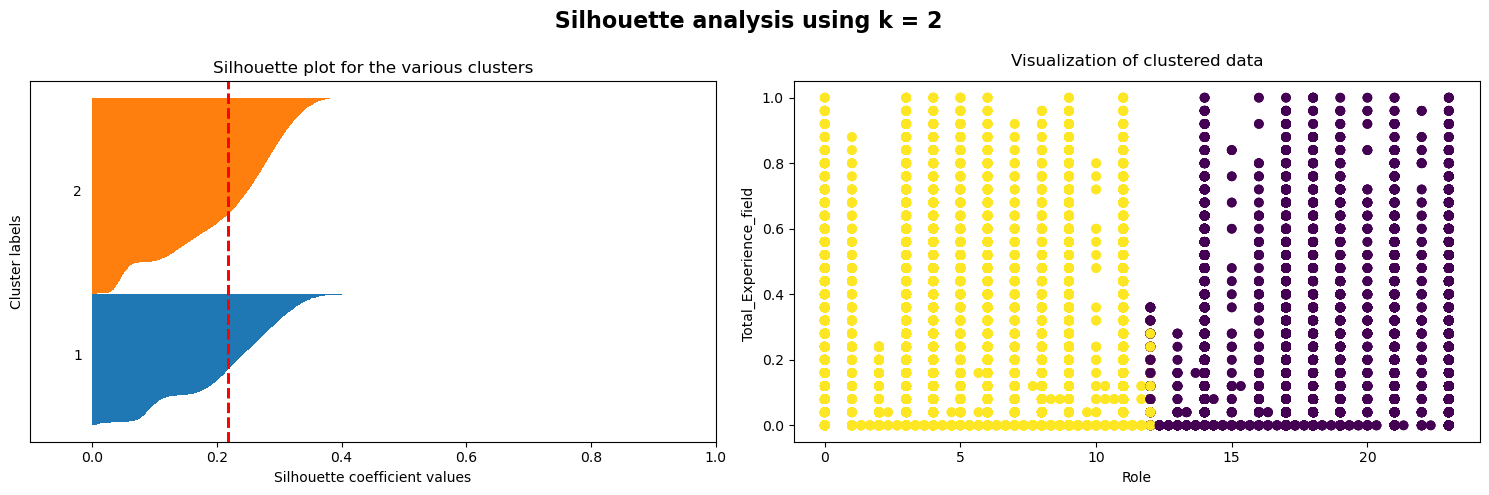

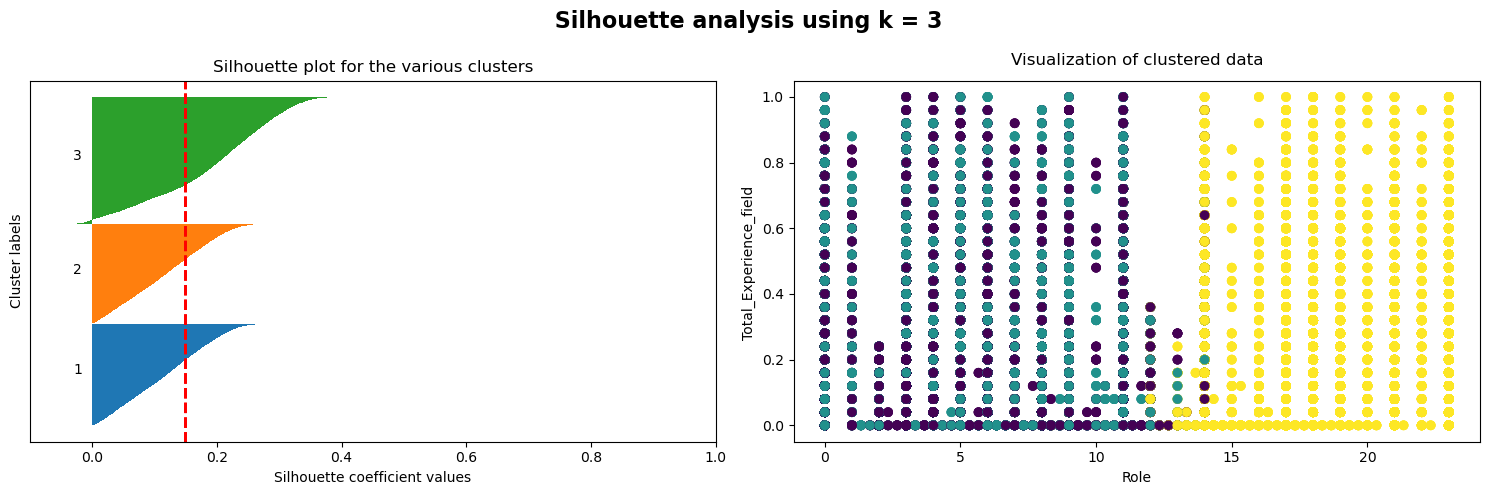

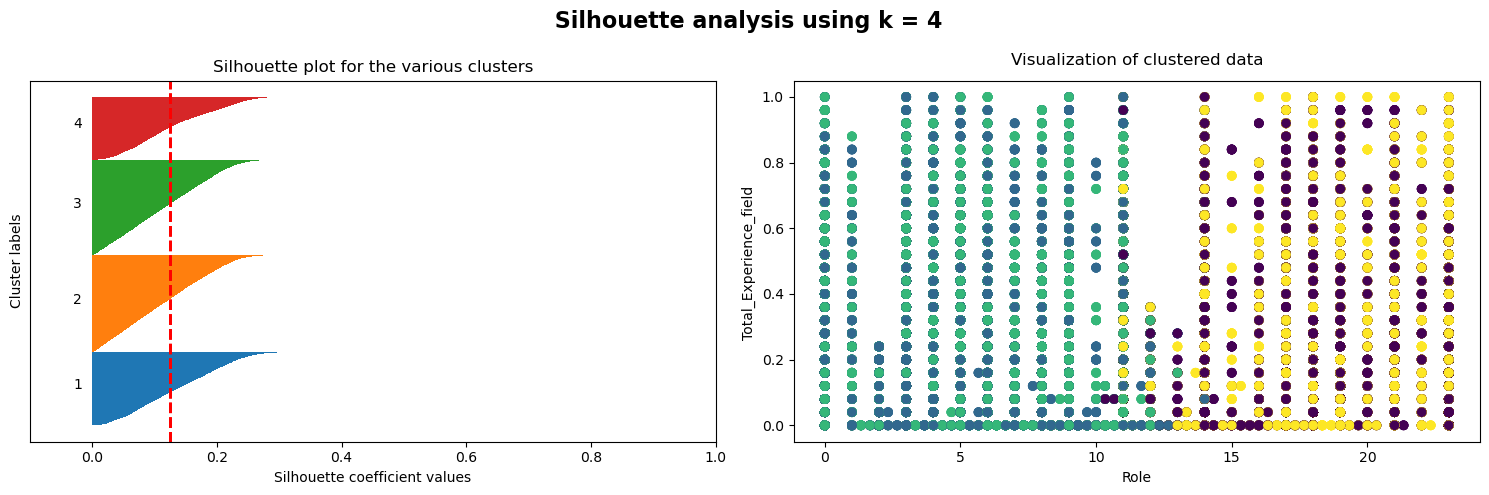

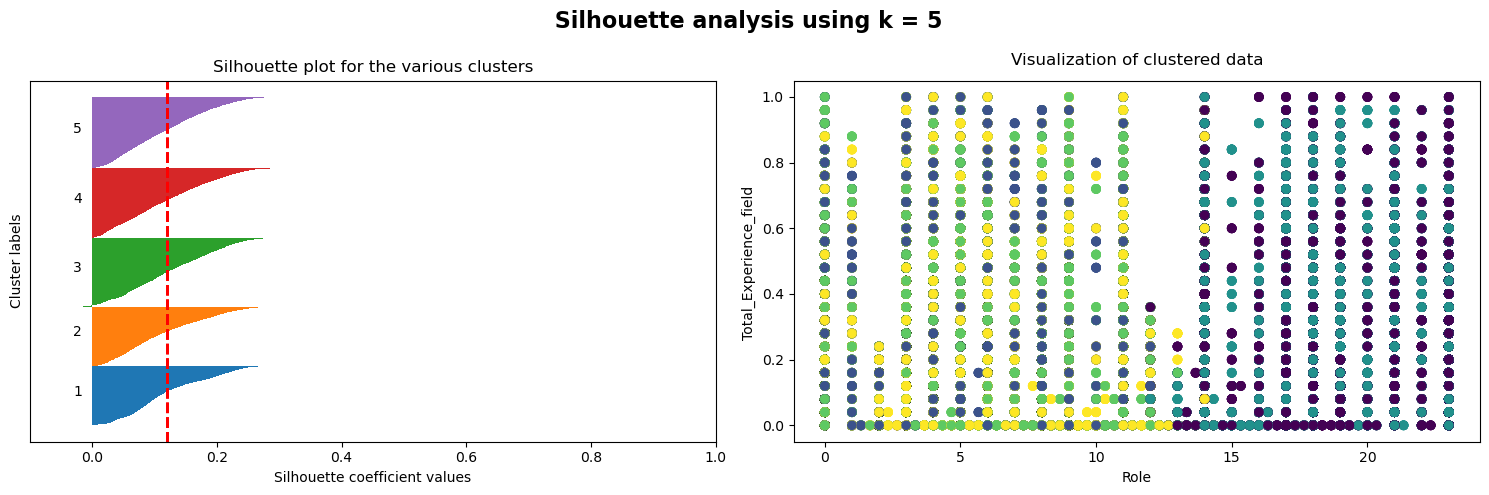

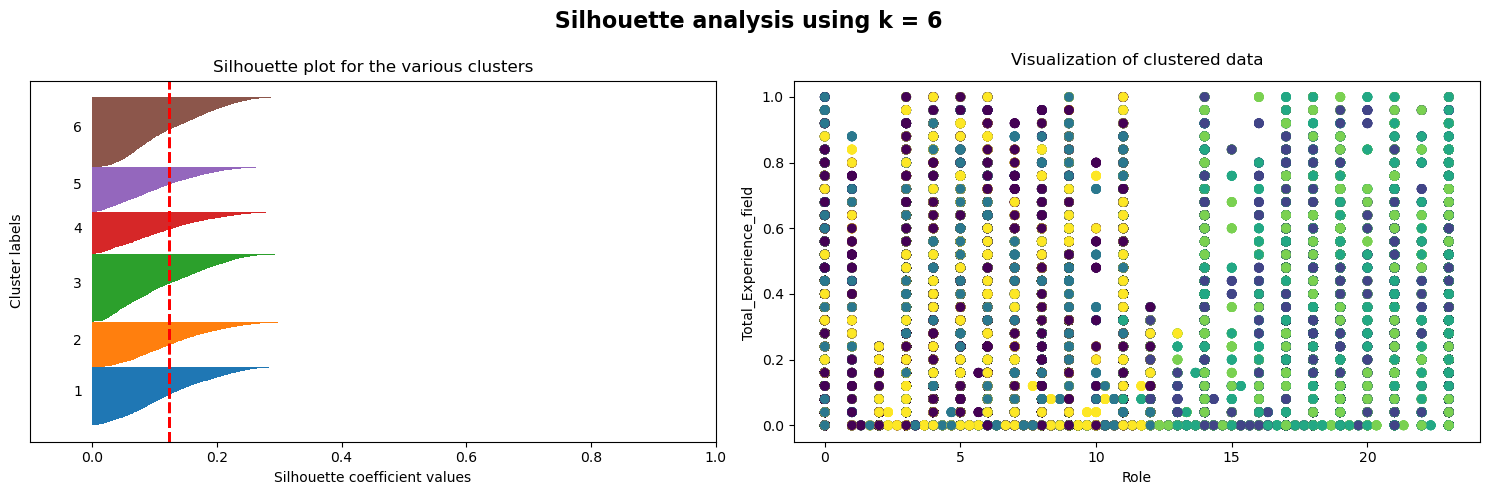

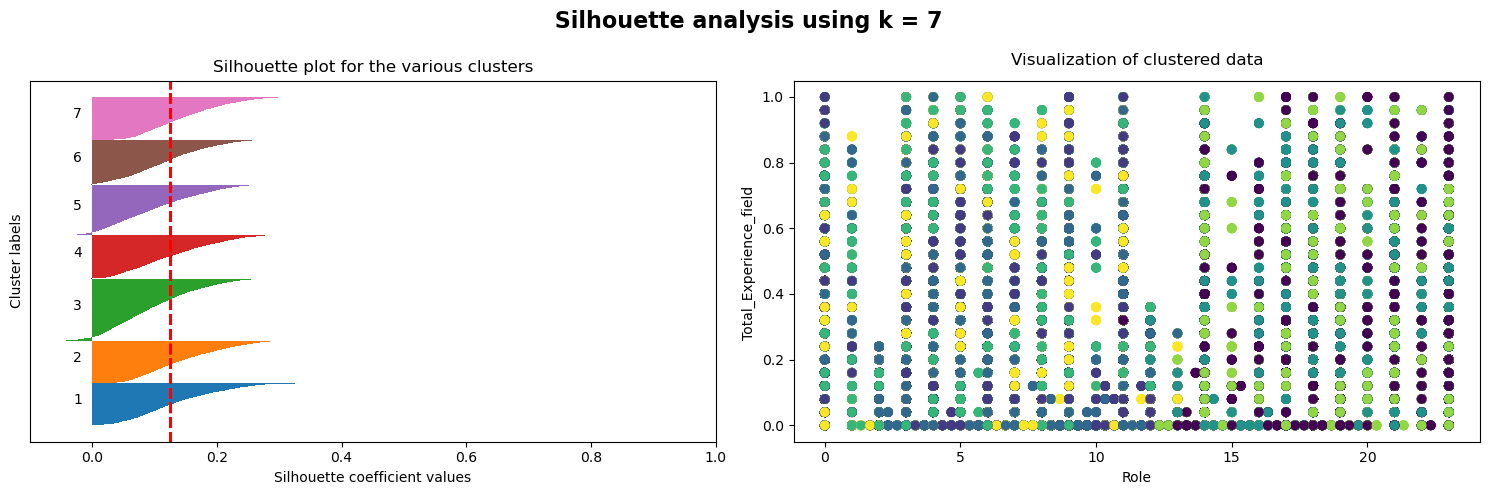

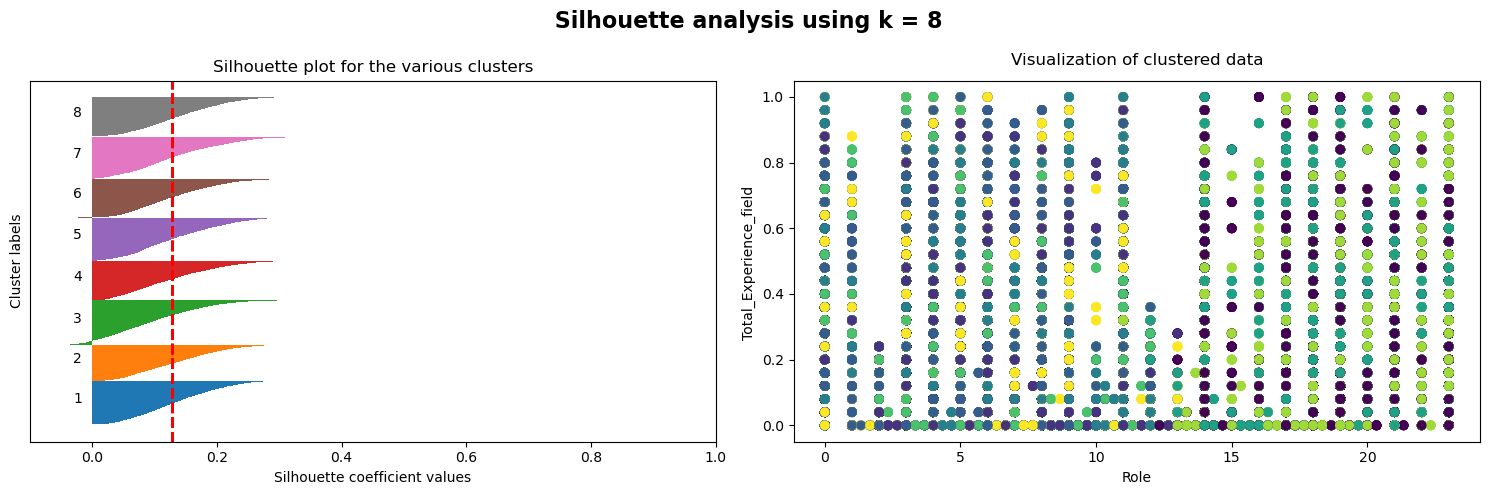

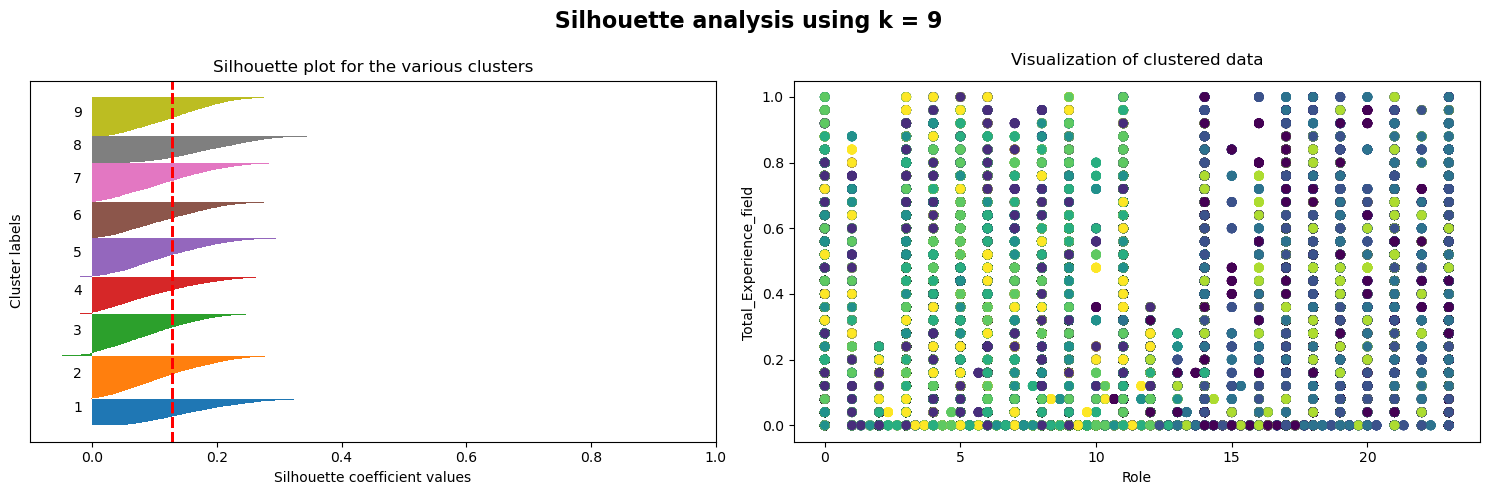

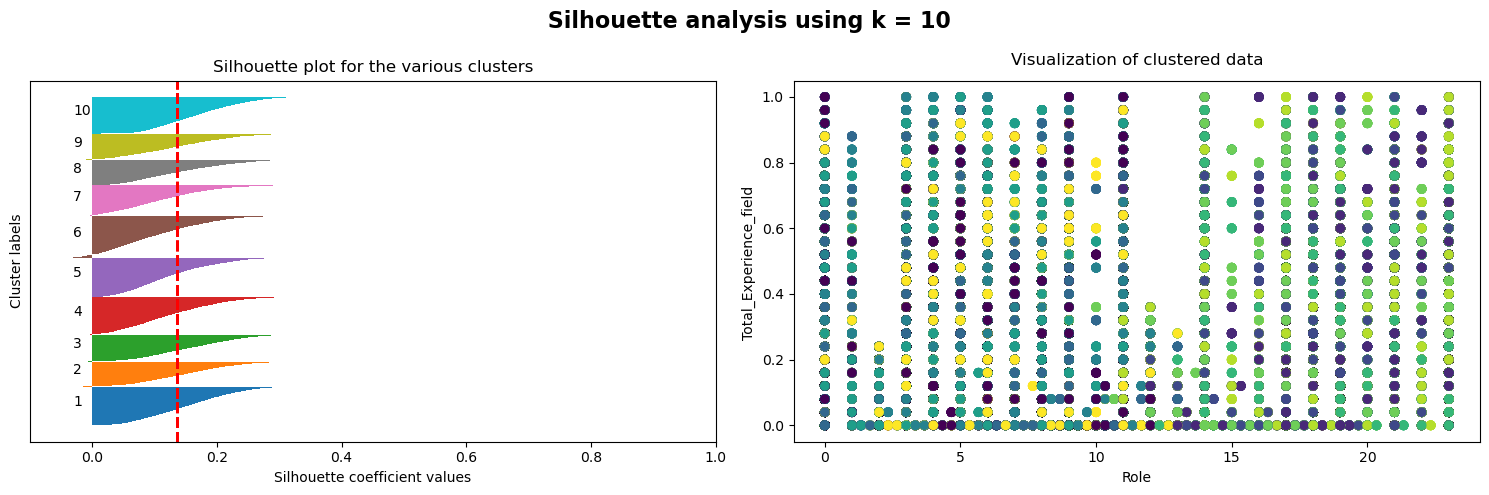

In [69]:
silhoutte_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=1)
    labels = kmeans.fit_predict(hr_imputed_df)  #1
    hr_imputed_df['Kmeans'] = labels  #2

    print('The Silhoutte score for {} is {}'.format(k,silhouette_score(hr_imputed_df,labels,random_state=1)))
    silhoutte_scores.append(silhouette_score(hr_imputed_df,labels,random_state=1))
    silhouette_vals = silhouette_samples(hr_imputed_df,labels)

    fig, ax = plt.subplots(1,2,figsize=(15,5))

    y_ticks = []
    y_lower = y_upper = 0

    for i,cluster in enumerate(np.unique(labels)):
        cluster_silhouette_vals = silhouette_vals[labels ==cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)

        ax[0].barh(range(y_lower,y_upper),
        cluster_silhouette_vals,height =1);
        ax[0].text(-0.03,(y_lower+y_upper)/2,str(i+1))
        y_lower += len(cluster_silhouette_vals)

        # Get the average silhouette score
        avg_score = np.mean(silhouette_vals)
        ax[0].axvline(avg_score,linestyle ='--',
        linewidth =2,color = 'red')
        ax[0].set_yticks([])
        ax[0].set_xlim([-0.1, 1])
        ax[0].set_xlabel('Silhouette coefficient values')
        ax[0].set_ylabel('Cluster labels')
        ax[0].set_title('Silhouette plot for the various clusters');

        # scatter plot of data colored with labels

        ax[1].scatter(hr_imputed_df['Role'],   #3
        hr_imputed_df['Total_Experience_field'] , c = labels);   #4
        ax[1].set_xlabel('Role')
        ax[1].set_ylabel('Total_Experience_field ')
        ax[1].set_title('Visualization of clustered data', y=1.02)

        plt.tight_layout()
        plt.suptitle(f' Silhouette analysis using k = {k}',fontsize=16,fontweight = 'semibold')

In [70]:
kmeans = KMeans(n_clusters=2,random_state=1)
labels = kmeans.fit_predict(hr_imputed_df) 
hr_imputed_df['Kmeans'] = labels
hr_imputed_df.groupby('Kmeans').mean()

,Total_Experience,Total_Experience_field,Current_CTC,Companies_worked,Publications,Certifications,International_degree,Expected_CTC,Department,Role,Designation,Education,Grad_Spec,University_Grad,PG_Spec,University_PG,Curent_Location,Preferred_location,Inhand_Offer,Last_Appraisal_Rating
Kmeans,,,,,,,,,,,,,,,,,,,,
0,0.495972,0.248764,0.436948,0.575223,0.509918,0.153487,0.091400,0.376694,5.411321,5.574579,7.858548,1.501099,4.958430,5.983945,4.940155,5.978105,6.975751,6.948504,0.307641,1.927520
1,0.505219,0.252539,0.445120,0.588020,0.513058,0.156752,0.067268,0.382968,5.914018,18.327051,7.893200,1.489323,4.907803,6.036959,4.914754,6.042105,6.866065,7.053333,0.296842,1.928321


In [71]:
hr_imputed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24986 entries, 0 to 24985
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total_Experience        24986 non-null  float64
 1   Total_Experience_field  24986 non-null  float64
 2   Current_CTC             24986 non-null  float64
 3   Companies_worked        24986 non-null  float64
 4   Publications            24986 non-null  float64
 5   Certifications          24986 non-null  float64
 6   International_degree    24986 non-null  float64
 7   Expected_CTC            24986 non-null  float64
 8   Department              24986 non-null  float64
 9   Role                    24986 non-null  float64
 10  Designation             24986 non-null  float64
 11  Education               24986 non-null  float64
 12  Grad_Spec               24986 non-null  float64
 13  University_Grad         24986 non-null  float64
 14  PG_Spec                 24986 non-null

## Model Building

Linear Regression

In [74]:
X=hr_imputed_df.drop(["Expected_CTC","Kmeans"], axis=1)
y=hr_imputed_df["Expected_CTC"]

In [89]:
import statsmodels.api as SM
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size = 0.3)

In [77]:
X_train.shape

(17490, 19)

In [78]:
X_test.shape

(7496, 19)

Without adding the constant as intercept

In [91]:

def train_model_check_vif(X_train, y_train, vif_threshold=5):
    # Add an intercept to X_train
    #X_train = SM.add_constant(X_train)  # Adds a column for the intercept
    
    while True:
        # Train the OLS model
        olsmod = SM.OLS(y_train, X_train)
        olsres = olsmod.fit()
        
        # Print model summary
        print(
            "R-squared:",
            np.round(olsres.rsquared, 3),
            "\nAdjusted R-squared:",
            np.round(olsres.rsquared_adj, 3),
        )
        print(olsres.summary())
        
        # Calculate VIF
        vif = pd.DataFrame()
        vif["Feature"] = X_train.columns
        vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
        
        # Print VIF for debugging
        print(vif)
        
        # Stop if the highest VIF is below the threshold
        max_vif = vif["VIF"].max()
        max_feature = vif.loc[vif["VIF"].idxmax(), "Feature"]
        
        if math.floor(max_vif) > vif_threshold :  # Avoid removing intercept
            print(f"Removing feature '{max_feature}' with VIF = {max_vif}")
            X_train = X_train.drop(columns=[max_feature])
        else:
            break
        
    return X_train


In [93]:
X_train_rm = train_model_check_vif(X_train, y_train)

R-squared: 0.995 
Adjusted R-squared: 0.995
                                 OLS Regression Results                                
Dep. Variable:           Expected_CTC   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                          1.838e+05
Date:                Fri, 20 Dec 2024   Prob (F-statistic):                        0.00
Time:                        11:38:19   Log-Likelihood:                          36141.
No. Observations:               17490   AIC:                                 -7.224e+04
Df Residuals:                   17471   BIC:                                 -7.210e+04
Df Model:                          19                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.0

In [95]:
X_train_rm.shape

(17490, 15)

In [136]:
X_train_rmc = sm.add_constant(X_train_rm)
final_model = sm.OLS(y_train, X_train_rm).fit()
print(final_model.summary())

                                 OLS Regression Results                                
Dep. Variable:           Expected_CTC   R-squared (uncentered):                   0.851
Model:                            OLS   Adj. R-squared (uncentered):              0.851
Method:                 Least Squares   F-statistic:                              6662.
Date:                Fri, 20 Dec 2024   Prob (F-statistic):                        0.00
Time:                        12:13:36   Log-Likelihood:                          6428.1
No. Observations:               17490   AIC:                                 -1.283e+04
Df Residuals:                   17475   BIC:                                 -1.271e+04
Df Model:                          15                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

R-squared and Adjusted R-squared value for the final model is 0.42 which means the model can explain 42% of variance in
Expected Salary with changes in the predictor variables. The model will not able to predict the expected salary correctly..

## Check for Linear Regression Assumption

1. Linear Relation
2. Independence
3. Homoscedasticity
4. Normality of Error Terms
5. No Strong Multicolinearity

Check Linearity

In [173]:
hr_pred = pd.DataFrame()

hr_pred["Actual Values"] = y_train.values.flatten()  # actual values
hr_pred["Fitted Values"] = final_model.fittedvalues.values  # predicted values
hr_pred["Residuals"] = final_model.resid.values  # residuals

hr_pred.head()

,Actual Values,Fitted Values,Residuals
0,0.105222,0.309463,-0.204241
1,0.395586,0.469439,-0.073853
2,0.443528,0.448839,-0.005311
3,0.576993,0.561181,0.015812
4,0.345721,0.375823,-0.030102


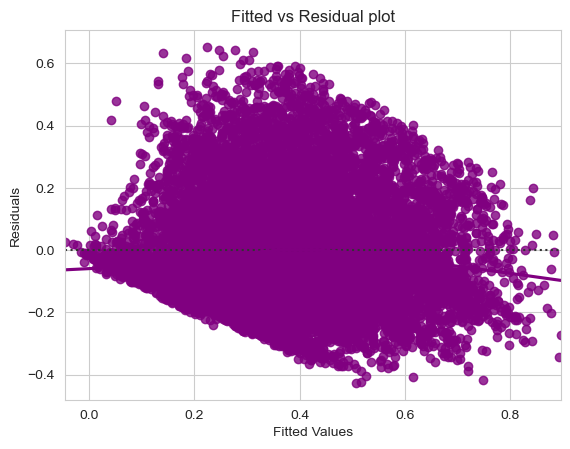

In [141]:
sns.set_style("whitegrid")
sns.residplot(
    data=hr_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

We see that there is no specific pattern between residual and predicted salary. so we can conclude
that predicted values follow linear relationship with actual values

## Check if residual is normally distributed or not

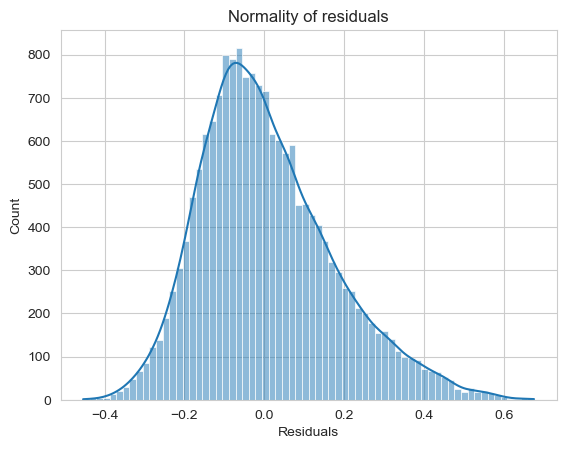

In [123]:
sns.histplot(hr_pred["Residuals"], kde=True)
plt.title("Normality of residuals")
plt.show()

We see from the above graph that residual is pretty normally distributed

## Test for HOMOSCEDASTICITY - check if the variance of the residuals are symmetrically distributed across
## the regression line

In [105]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

In [143]:
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(hr_pred["Residuals"], X_train_rm)
lzip(name, test)

[('F statistic', 0.9989103430372935), ('p-value', 0.5203101688158874)]

Since p-value > 0.05 we can say that the residuals are homoscedastic.

In [175]:
final_model.params

Total_Experience_field    0.440276
Companies_worked          0.216451
Publications              0.028748
Certifications           -0.036370
International_degree      0.041224
Department                0.006876
Role                      0.001870
Designation               0.002060
Education                -0.041612
Grad_Spec                 0.004504
University_Grad           0.003231
Curent_Location           0.002763
Preferred_location        0.003205
Inhand_Offer              0.031584
Last_Appraisal_Rating     0.009206
dtype: float64

In [177]:
X_test_rm = X_test.drop(["University_PG","PG_Spec","Current_CTC","Total_Experience"], axis=1)

In [179]:
#X_test_rm = sm.add_constant(X_test_rm)
y_pred= final_model.predict(X_test_rm)

In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

Determingin the model performance KPIS (MAE, MSE, RMSE, MAPE) on train data

In [181]:
# let's check the RMSE on the train data
mae = mean_absolute_error(y_train, hr_pred["Fitted Values"])
print(f"Mean Absolute Error (MAE) on the train data: {mae}")
mean_absolute_percentage_error
# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_train, hr_pred["Fitted Values"])
print(f"Mean Squared Error (MSE) on the train data: {mse}")

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE) on the train data: {rmse}")

# 4. Mean Absolute Percentage Error (MAPE)

mape = mean_absolute_percentage_error(y_train, hr_pred["Fitted Values"])
print(f"Mean Absolute Percentage Error (MAPE) on the train data: {mape:.2f}")


Mean Absolute Error (MAE) on the train data: 0.13151730181913399
Mean Squared Error (MSE) on the train data: 0.02807330877595698
Root Mean Squared Error (RMSE) on the train data: 0.16755091398126415
Mean Absolute Percentage Error (MAPE) on the train data: 0.56


In [183]:
# let's check the RMSE on the test data
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE) on the test data: {mae}")

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) on the test data: {mse}")

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE) on the test data: {rmse}")

# 4. Mean Absolute Percentage Error (MAPE)

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE) on the test data: {mape :.2f}")


Mean Absolute Error (MAE) on the test data: 0.13430523340740752
Mean Squared Error (MSE) on the test data: 0.0291567286153503
Root Mean Squared Error (RMSE) on the test data: 0.170753414652095
Mean Absolute Percentage Error (MAPE) on the test data: 16674229348.48


In [185]:
ss_total = ((y_test - y_test.mean()) ** 2).sum()  # Total sum of squares
ss_residual = ((y_test - y_pred) ** 2).sum()  # Residual sum of squares
r_squared = 1 - (ss_residual / ss_total)
print("R-squared value for the test data:", r_squared)

R-squared value for the test data: 0.38097791207687737


Linear Regression Model using sklearn

In [187]:
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model = linear_model.fit(X_train, y_train)

In [189]:
print(f"R-squared for train data",linear_model.score(X_train,y_train))
print(f"R-squared for test data",linear_model.score(X_test,y_test))

R-squared for train data 0.979539793266336
R-squared for test data 0.9793904726521618


In [193]:
print(f"MAE of train data is" , mean_absolute_error(y_train,linear_model.predict(X_train)))
print(f"MSE of train data is" , mean_squared_error(y_train,linear_model.predict(X_train)))
print(f"RMSE of train data is" , np.sqrt(mean_squared_error(y_train,linear_model.predict(X_train))))

print(f"MAE of test data is" , mean_absolute_error(y_test,linear_model.predict(X_test)))
print(f"MSE of test data is" , mean_squared_error(y_test,linear_model.predict(X_test)))
print(f"RMSE of test data is" , np.sqrt(mean_squared_error(y_test,linear_model.predict(X_test))))

MAE of train data is 0.02250496036393746
MSE of train data is 0.0009382292620468492
RMSE of train data is 0.03063052826914432
MAE of test data is 0.02285887774378429
MSE of test data is 0.0009707349826363307
RMSE of test data is 0.031156620205605272


Lasso Regression Model

In [195]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [197]:
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)

# Make predictions
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

# Evaluate the model
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")

print(f"Training R2: {train_r2:.4f}")
print(f"Testing R2: {test_r2:.4f}")


# Coefficients of the model
print("Coefficients:", lasso.coef_)
print("Intercept:", lasso.intercept_)

Training MAE: 0.1771
Testing MAE: 0.1785
Training MSE: 0.0459
Testing MSE: 0.0471
Training RMSE: 0.2141
Testing RMSE: 0.2171
Training R2: 0.0000
Testing R2: -0.0004
Coefficients: [ 0.  0.  0.  0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0. -0.  0.  0.  0.
  0.]
Intercept: 0.37783609168666515


Decision Tree Regressor Model

In [201]:
from sklearn import tree
from sklearn.model_selection import GridSearchCV

In [208]:
X_train_dr,X_test_dr,y_train_dr,y_test_dr=train_test_split(X,y,test_size=0.3,random_state=1)

In [210]:
dtr = tree.DecisionTreeRegressor( )
dtr.fit(X_train_dr,y_train_dr)
print(f"R2 of train data",dtr.score(X_train_dr,y_train_dr))
print(f"R2 of test data",dtr.score(X_test_dr,y_test_dr))

print(f"MAE of train data",mean_absolute_error(y_train_dr,dtr.predict(X_train_dr)))
print(f"MAE of test data",mean_absolute_error(y_test_dr,dtr.predict(X_test_dr)))


print(f"MSE of train data",mean_squared_error(y_train_dr,dtr.predict(X_train_dr)))
print(f"MSE of test data",mean_squared_error(y_test_dr,dtr.predict(X_test_dr)))

print(f"RMSE of train data",np.sqrt(mean_squared_error(y_train_dr,dtr.predict(X_train_dr))))
print(f"RMSE of test data",np.sqrt(mean_squared_error(y_test_dr,dtr.predict(X_test_dr))))

R2 of train data 1.0
R2 of test data 0.9988610013889774
MAE of train data 0.0
MAE of test data 0.0028591360458362853
MSE of train data 0.0
MSE of test data 5.242537087853148e-05
RMSE of train data 0.0
RMSE of test data 0.007240536642993493


In [212]:
param_grid = {
    'max_depth': [5,10,15,20,25,30],
    'min_samples_leaf': [3, 5, 10, 15],
    'min_samples_split': [5, 10,15,30,35,40],
}

dtr_tuned=tree.DecisionTreeRegressor(random_state=123)

grid_search = GridSearchCV(estimator = dtr_tuned, param_grid = param_grid, cv = 3)


grid_search.fit(X_train_dr,y_train_dr)

print(grid_search.best_params_)


{'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 15}


In [216]:
dtr_tuned = tree.DecisionTreeRegressor(max_depth=15,min_samples_split=15,min_samples_leaf=3,random_state=123)
dtr_tuned.fit(X_train_dr,y_train_dr)
print(f"R2 of train data",dtr_tuned.score(X_train_dr,y_train_dr))
print(f"R2 of test data",dtr_tuned.score(X_test_dr,y_test_dr))

print(f"MAE of train data",mean_absolute_error(y_train_dr,dtr_tuned.predict(X_train_dr)))
print(f"MAE of test data",mean_absolute_error(y_test_dr,dtr_tuned.predict(X_test_dr)))


print(f"MSE of train data",mean_squared_error(y_train_dr,dtr_tuned.predict(X_train_dr)))
print(f"MSE of test data",mean_squared_error(y_test_dr,dtr_tuned.predict(X_test_dr)))

print(f"RMSE of train data",np.sqrt(mean_squared_error(y_train_dr,dtr_tuned.predict(X_train_dr))))
print(f"RMSE of test data",np.sqrt(mean_squared_error(y_test_dr,dtr_tuned.predict(X_test_dr))))

R2 of train data 0.9995098915590387
R2 of test data 0.998910992205974
MAE of train data 0.0023681280507223696
MAE of test data 0.0034715614567713804
MSE of train data 2.270310491669549e-05
MSE of test data 5.0124413619930966e-05
RMSE of train data 0.004764777530661373
RMSE of test data 0.007079859717531906


In [218]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training the model
random_forest_model.fit(X_train, y_train)

# Making predictions on the test set
y_pred_train = random_forest_model.predict(X_train)
y_pred_test = random_forest_model.predict(X_test)

# Evaluating the model on train data
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)

print(f"Mean Absolute Error (MAE) on Train Data: {mae}")
print(f"Mean Squared Error (MSE) on Train Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Train Data: {rmse}")
print(f"R² Score on Train Data: {r2}")


# Evaluating the model on test data
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE) on Test Data: {mae}")
print(f"Mean Squared Error (MSE) on Test Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse}")
print(f"R² Score on Test Data: {r2}")


Mean Absolute Error (MAE) on Train Data: 0.0009652106100480275
Mean Squared Error (MSE) on Train Data: 4.452725886054406e-06
Root Mean Squared Error (RMSE) on Train Data: 0.0021101483090186827
R² Score on Train Data: 0.999902898261819
Mean Absolute Error (MAE) on Test Data: 0.0026767084526839093
Mean Squared Error (MSE) on Test Data: 4.624683597738522e-05
Root Mean Squared Error (RMSE) on Test Data: 0.006800502626819963
R² Score on Test Data: 0.9990181404318629


Hypertuning the parameters in Random Forest Model

In [220]:
# Importing necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
random_forest_ht = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],              # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],            # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],            # Minimum number of samples to split a node
    'min_samples_leaf': [1, 2, 4],              # Minimum number of samples required at a leaf node
    'max_features': ['auto', 'sqrt', 'log2']    # Number of features considered for splitting
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=random_forest_ht, 
                           param_grid=param_grid, 
                           cv=5,                     # 5-fold cross-validation
                           n_jobs=-1,               # Use all available cores
                           scoring='neg_mean_squared_error',  # Evaluation metric
                           verbose=2)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

# Evaluate the best model on the train set
y_pred_train = best_model.predict(X_train)
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)

print(f"Mean Absolute Error (MAE) on Train Data: {mae}")
print(f"Mean Squared Error (MSE) on Train Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Train Data: {rmse}")
print(f"R² Score on Train Data: {r2}")


# Evaluating the model on test data
y_pred_test = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE) on Test Data: {mae}")
print(f"Mean Squared Error (MSE) on Test Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse}")
print(f"R² Score on Test Data: {r2}")


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mean Absolute Error (MAE) on Train Data: 0.001132536799543079
Mean Squared Error (MSE) on Train Data: 6.897089774079738e-06
Root Mean Squared Error (RMSE) on Train Data: 0.0026262310968533857
R² Score on Train Data: 0.9998495933900735
Mean Absolute Error (MAE) on Test Data: 0.0026466313531529587
Mean Squared Error (MSE) on Test Data: 4.432037789310119e-05
Root Mean Squared Error (RMSE) on Test Data: 0.006657355172521682
R² Score on Test Data: 0.9990590407715876


In [222]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [226]:
# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Evaluate the best model on the train set

mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)

print(f"Mean Absolute Error (MAE) on Train Data: {mae}")
print(f"Mean Squared Error (MSE) on Train Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Train Data: {rmse}")
print(f"R² Score on Train Data: {r2}")


# Evaluating the model on test data

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE) on Test Data: {mae}")
print(f"Mean Squared Error (MSE) on Test Data: {mse}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse}")
print(f"R² Score on Test Data: {r2}")

Mean Absolute Error (MAE) on Train Data: 0.0024866159339837707
Mean Squared Error (MSE) on Train Data: 2.201667906726007e-05
Root Mean Squared Error (RMSE) on Train Data: 0.004692193417503169
R² Score on Train Data: 0.9995198766191515
Mean Absolute Error (MAE) on Test Data: 0.00276844021511807
Mean Squared Error (MSE) on Test Data: 4.183054673399726e-05
Root Mean Squared Error (RMSE) on Test Data: 0.0064676538817408325
R² Score on Test Data: 0.9991119019997116
